<a href="https://colab.research.google.com/github/FDB1228/Optimization_methods/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

styles = [  dict(selector="caption",
                props=[ ("text-align", "right"),
                        ("font-size", "14pt"),
                        ("color", "white"),
                        ('font-family', 'Times New Roman')]),

            dict(selector="th",
                props=[ ("text-align", "center"),
                        ("font-size", "13pt"),
                        ("color", "black"),
                        ("background-color", "white"),
                        ("border","2px solid black"),
                        ("font-weight","bold"),
                        ('font-family', 'Times New Roman')]),

            dict(selector="td",
                props=[ ('font-size', '11pt'),
                        ("border", "2px solid black"),
                        ("background-color", "white"),
                        ("color", "black"),
                        ('font-family', 'Times New Roman')])]



def style_table(tb, caption):
    return display(tb.style.set_caption(caption).set_table_styles(styles))



plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.size"] = 14
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.latex.preamble'] = r'''
\usepackage[utf8]{inputenc}
\usepackage[russian]{babel}
\usepackage{amsmath}
'''

In [ ]:
def rosenbrock1(X):
    return (X[0]*X[0] - X[1])*(X[0]*X[0] - X[1]) + (X[0]-1)*(X[0]-1)
def antrigrad_rosenbrock1(X):
    return np.array([2*(-1 + X[0]) + 4*X[0]*(X[0]*X[0] - X[1]), -2*(X[0]*X[0] - X[1])])* (-1)
def Hesse_inv_r1(X):
    return np.array([[2/(4 + 8*X[0]**2 - 8*X[1]), (4*X[0])/(4 + 8*X[0]**2 - 8*X[1])],
                     [(4*X[0])/(4 + 8*X[0]**2 - 8*X[1]), (2 + 8*X[0]**2 + 4*(X[0]**2 - X[1]))/(4 + 8*X[0]**2 - 8*X[1])]])
def Hesse_r1(X):
    return np.array([[2 + 8*X[0]**2 + 4*(X[0]**2 - X[1]), -4*X[0]],[-4*X[0], 2]])



def antrigrad_rosenbrock2(X):
    return np.array([2*(-1 + X[0]) + 60*X[0]*(X[0]*X[0] - X[1]), -30*(X[0]*X[0] - X[1])])* (-1)
def rosenbrock2(X):
    return 15*(X[0]*X[0] - X[1])*(X[0]*X[0] - X[1]) + (X[0]-1)*(X[0]-1)
def Hesse_inv_r2(X):
    return np.array([[30/(60 + 1800*X[0]**2 - 1800*X[1]), (60*X[0])/(60 + 1800*X[0]**2 - 1800*X[1])],
                     [(60*X[0])/(60 + 1800*X[0]**2 - 1800*X[1]), (2 + 15*(8*X[0]**2 + 4*(X[0]**2 - X[1])))/(60 + 1800*X[0]**2 - 1800*X[1])]])
def Hesse_r2(X):
    return np.array([[2 + 120*X[0]**2 + 60*(X[0]**2 - X[1]), -60*X[0]],[-60*X[0], 30]])

In [ ]:
def f(X) -> float:
    return 10*X[0]*X[0] - 4*X[0]*X[1] + 7*X[1]*X[1] - 4*np.sqrt(5) * (5 * X[0] - X[1]) - 16
def antigrad_f(X)->np.array:
    return np.array([-20*np.sqrt(5) +20*X[0] -4*X[1], 4*np.sqrt(5) -4*X[0] +14*X[1]])*(-1)
def Hesse_inv_f(X):
    return np.array([[7/132, 1/66],[1/66, 5/66]])
def Hesse_f(x):
    return np.array([[20, -4], [-4, 14]])

In [ ]:
def g1_1(X):
    return -X[0]
def g1_2(X):
    return -X[0]
def g1_3(X):
    return X[0] +X[1] - 25
g_1 = [g1_1, g1_2, g1_3]

def Omega1_Hesse1(X):
    return np.array([[-2/X[0]**3, 0], [0,0]])
def Omega1_Hesse2(X):
    return np.array([[0,0],[0, -2/X[1]**3]])
def Omega1_Hesse3(X):
    return np.array([[2/(-25 + X[0] + X[1])**3,2/(-25 + X[0] + X[1])**3],[2/(-25 + X[0] + X[1])**3, 2/(-25 + X[0] + X[1])**3]])
g_1_Hesse = [Omega1_Hesse1, Omega1_Hesse2, Omega1_Hesse3]
def Omega1_antigrad_1(X):
    return np.array([-1/X[0]**2, 0])
def Omega1_antigrad_2(X):
    return np.array([0, -1/X[1]**2])
def Omega1_antigrad_3(X):
    return np.array([1/(X[0]+X[1] - 25)**2, 1/(X[0]+X[1] - 25)**2])

g_1_antigrad = [Omega1_antigrad_1, Omega1_antigrad_2, Omega1_antigrad_3]


def Omega1_antigrad_1_Outer(X):
    if g1_1(X) > 0:
        return np.array([2/X[0]**3, 0])
    return np.zeros(2)
def Omega1_antigrad_2_Outer(X):
    if g1_2(X) > 0:
        return np.array([0, 2/X[1]**3])
    return np.zeros(2)
def Omega1_antigrad_3_Outer(X):
    if g1_3(X)>0:
        return np.array([2/(-25 + X[0] +X[1])**3, 2/(-25 + X[0] +X[1])**3])
    return np.zeros(2)
g_1_antigrad_outer = [Omega1_antigrad_1_Outer, Omega1_antigrad_2_Outer, Omega1_antigrad_3_Outer]
def Omega1_Hesse_1_Outer(X):
    if g1_1(X) > 0:
        return np.array([[6/X[0]**4, 0],[0,0]])
    return np.zeros([2,2])

def Omega1_Hesse_2_Outer(X):
    if g1_2(X) > 0:
        return np.array([[0, 0],[0,6/X[1]**4]])
    return np.zeros([2,2])

def Omega1_Hesse_3_Outer(X):
    if g1_3(X) > 0:
        return np.array([[6/(-25 + X[0] + X[1])**4, 6/(-25 + X[0] + X[1])**4],[6/(-25 + X[0] + X[1])**4,6/(-25 + X[0] + X[1])**4]])
    return np.zeros([2,2])
g_1_hesse_outer = [Omega1_Hesse_1_Outer, Omega1_Hesse_2_Outer, Omega1_Hesse_3_Outer]


In [ ]:
def g2(X):
    return (((X[0] + 3)**2) / 8 + ((X[1] + 4)**2) / 81) -1
def Omega2_Hesse(X):
    return np.array([[(104976*(2707 + 243*X[0]*(6+X[0]) - 8 * X[1] * (8 + X[1])))/(209 + 81 * X[0] * (6 + X[0]) + 8*X[1]*(8+X[1]))**3, (3359232*(3+X[0])*(4+X[1]))/(209 + 81 * X[0] * (6 + X[0]) + 8*X[1]*(8+X[1]))**3],[(3359232*(3+X[0])*(4+X[1]))/(209 + 81 * X[0] * (6 + X[0]) + 8*X[1]*(8+X[1]))**3, - (31104*(-101 + 27 *X[0]*(6+X[0]) - 8 * X[1] * (8 + X[1])))/(209 + 81 * X[0] * (6 + X[0]) + 8*X[1]*(8+X[1]))**3]])
def Omega2_antigrad(X):
    return np.array([(3+X[0])/(4*(-1 + 1/8 * (3+X[0])**2 + 1/81 * (4+X[1])**2)**2), (8 + 2*X[1]) / (81 * (-1 + 1/8 * (3+X[0])**2 + 1/81 * (4+X[1])**2)**2)])
def Omega2_Hesse_Outer(X):
    matrix = np.zeros([2,2])
    if g2(X) > 0:
        matrix[0][0] = (1667 + 243*X[0]*(6+X[0]) + 8*X[1]*(8 + X[1]))/(1296)
        matrix[1][0] = 1/81 * (3 +X[0]) * (4 + X[1])
        matrix[0][1] = 1/81 * (3 +X[0]) * (4 + X[1])
        matrix[1][1] =  (155 + 27*X[0]*(6+X[0]) + 8 * X[1] * (8 + X[1]))/4374
    return matrix
def Omega2_Antigrad_Outer(X):
    res = np.zeros(2)
    if g2(X) > 0:
        res[0]= -(3+X[0]) * (209 + 81*X[0]*(6+X[0]) + 8 * X[1] * (8 + X[1])) / 1296
        res[1] = -(4+X[1]) * (209 + 81*X[0]*(6+X[0]) + 8 * X[1] * (8 + X[1])) / 13122
    return res

In [ ]:
g2(np.array([1,1]))

np.float64(1.308641975308642)

In [ ]:
Omega2_Hesse_Outer(np.array([0,0]))

array([[1.28626543, 0.14814815],
       [0.14814815, 0.03543667]])

In [ ]:
p1_omega1 = np.array([0.01,0.01])
p2_omega1 = np.array([10,5])
p1_omega2 = np.array([-2, 2])
p2_omega2 = np.array([-4,-4])

In [ ]:
def NumericalAntigrad(f, x0):
    delta = 1e-10
    res = []
    n = len(x0)
    for i in range(n):
        e =np.zeros(n)
        e[i] = delta
        res += [(f(x0 + e) - f(x0 - e))/ (2*delta)]
    return - np.array(res)

In [ ]:
def NumericalHesse(f, x0):
    delta = 1e-6
    n = len(x0)
    res = np.zeros((n, n))
    for i in range(n):
        e1 = np.zeros(n)
        e1[i] = delta
        for j in range(n):
            e2 = np.zeros(n)
            e2[j] = delta
            f1 = f(x0 + e1 + e2)
            f2 = f(x0 + e1 - e2)
            f3 = f(x0 - e1 + e2)
            f4 = f(x0 - e1 - e2)
            res[i][j] = (f1 - f2 - f3 + f4) / (4 * delta ** 2)
    return res

In [ ]:
np.linalg.inv(NumericalHesse(f, np.array([2,2])))

array([[0.05303303, 0.0151571 ],
       [0.0151571 , 0.07574514]])

In [ ]:
Hesse_f(np.array([2,2]))

array([[20, -4],
       [-4, 14]])

In [ ]:
def NewtonMethod(f, antigrad, H, x0, eps):
    x_next = x_prev = x0
    f_calls = grad_calls = 1
    iterations = 0
    f_trace = [f(x0)]
    trace = [x0]
    H_calls = 0
    prev_antigrad = antigrad(x_prev)

    while (np.linalg.norm(prev_antigrad) > eps) or iterations == 0:
        x_prev = x_next

        x_next = x_prev + np.dot(H(x_prev), prev_antigrad)
        print("iteration newton = ", iterations)
        print("antigrad", prev_antigrad)
        print("pk = ",np.dot(H(x_prev), prev_antigrad))
        H_calls += 1
        grad_calls += 1
        trace += [x_next]
        f_trace += [f(x_next)]
        prev_antigrad = antigrad(x_next)

        f_calls += 1
        iterations += 1
    print("iters =", iterations)
    return [x_next, f_trace[-1], len(trace)-1, f_calls, grad_calls,H_calls]



In [ ]:
NumericalHesse(f, np.array([1,1]))

array([[20.00177801, -3.99680289],
       [-3.99680289, 13.99769189]])

In [ ]:
sum([NumericalHesse(f, np.array([1,1])), NumericalHesse(f,np.array([1,1]))])

array([[40.00355602, -7.99360578],
       [-7.99360578, 27.99538379]])

In [ ]:
def inverse(M, X):
    res = np.zeros([2,2])
    matrix = M(X)
    det =  matrix[0][0] * matrix[1][1] - matrix[1][0] * matrix[0][1]
    temp = matrix[0][0]
    res[0][0] = matrix[1][1]/ det
    res[1][1] = matrix[0][0]/ det
    res[0][1] = -matrix[0][1]/det
    res[1][0] = -matrix[1][0]/det
    return res

In [ ]:
def InnerPenaltyMethod(f, g,Omega_Hesses,Hessef,Omega_antigrads,antigrad_f, x0, eps):
    trace = [x0]
    f_trace = [f(x0)]
    iterations = 0
    f_calls = 0
    grad_calls = 0
    hesse_calls = 0
    x_prev = x_next = x0
    gamma = 2
    O = lambda X: sum([Omega_Hesses[i](X) for i in range(len(Omega_Hesses))])
    A = lambda X: sum([Omega_antigrads[i](X) for i in range(len(Omega_antigrads))])
    h = lambda X: sum([1/g[i](X) for i in range(len(g))])
    print("O = ", O(np.array([1,1])))
    rk = 32
    fk = lambda X: f(X) - rk * h(X)
    while iterations == 0 or np.linalg.norm(x_next - x_prev) > eps:
        x_prev = x_next
        cur_antigrad = lambda X: antigrad_f(X) - rk * A(X)
        cur_Hesse = lambda X:  Hessef(X) - rk* O(X)
        # cur_Hesse_inv = lambda X: np.linalg.inv(cur_Hesse(X))
        print("cur_Hesse = ", cur_Hesse(np.array([-4,-4])))
        print("cur_antigrad = ", cur_antigrad(np.array([1,1])))
        print("antigrad  f= ", antigrad_f(np.array([1,1])))
        cur_Hesse_inv = lambda X: inverse(cur_Hesse,X)
        print("cur_Hesse_inv", cur_Hesse_inv(np.array([1,1])))
        print("fk =", fk(np.array([-1.1395602,  -1.53754415])))
        # cur_Hesse_inv= lambda X: np.linalg.inv(NumericalHesse(fk, X))
        Newton_res = NewtonMethod(fk, cur_antigrad,cur_Hesse_inv, x_prev, eps)
        print("newton res", Newton_res)
        f_calls += Newton_res[3]
        grad_calls += Newton_res[4]
        hesse_calls += Newton_res[5]
        x_next = Newton_res[0]
        trace += [x_next]
        f_trace += [f(x_next)]
        f_calls += 1
        print("suppose", fk(np.array([-4.93457,-10.5656])))

        rk /= gamma
        fk = lambda X: f(X) - rk * h(X)
        iterations += 1
        print("xnext = ", x_next)
        print(Newton_res[1])
        # if iterations == 2:
        #     break
    return [x_next, f_trace[-1], len(trace)-1, f_calls, grad_calls,hesse_calls, trace, f_trace]

In [ ]:
InnerPenaltyMethod(f, [g2], [Omega2_Hesse], Hesse_f, [Omega2_antigrad], antigrad_f, np.array([-4,-4]), 1e-2)

O =  [[ 0.74643456  0.11017484]
 [ 0.11017484 -0.00081611]]
cur_Hesse =  [[36.41982507 -4.        ]
 [-4.         15.03199798]]
cur_antigrad =  [ 10.03570629 -21.25114268]
antigrad  f=  [ 28.72135955 -18.94427191]
cur_Hesse_inv [[-0.12620365 -0.06771351]
 [-0.06771351  0.03496446]]
fk = 108.71282394172835
iteration newton =  0
antigrad [119.17033914  31.05572809]
pk =  [3.60437539 3.02509551]
iteration newton =  1
antigrad [-13526.83446001  -1554.27214751]
pk =  [-0.02576796 -0.03408405]
iteration newton =  2
antigrad [-5999.06518679  -689.39100132]
pk =  [-0.03835058 -0.05150761]
iteration newton =  3
antigrad [-2653.10940757  -304.83256074]
pk =  [-0.05695692 -0.07442996]
iteration newton =  4
antigrad [-1165.61541612  -133.69937762]
pk =  [-0.08401527 -0.09700533]
iteration newton =  5
antigrad [-503.9955453   -57.43181592]
pk =  [-0.12016411 -0.1052567 ]
iteration newton =  6
antigrad [-209.48295253  -23.48694283]
pk =  [-0.15510702 -0.09122588]
iteration newton =  7
antigrad [-78.

[array([-0.34456615, -1.10092537]),
 np.float64(-2.2833606977482077),
 12,
 86,
 74,
 62,
 [array([-4, -4]),
  array([-1.1395789 , -1.53747009]),
  array([-0.9259516 , -1.41070933]),
  array([-0.76330115, -1.31950143]),
  array([-0.64191818, -1.25395098]),
  array([-0.55260239, -1.20693312]),
  array([-0.48758762, -1.17329913]),
  array([-0.44059924, -1.14928535]),
  array([-0.40684717, -1.13218127]),
  array([-0.38270779, -1.12002064]),
  array([-0.36549834, -1.11138701]),
  array([-0.35325782, -1.10526413]),
  array([-0.34456615, -1.10092537])],
 [np.float64(335.10835055998655),
  np.float64(43.736793705190166),
  np.float64(30.07162147245471),
  np.float64(20.31905260239906),
  np.float64(13.39938050843471),
  np.float64(8.500682624953505),
  np.float64(5.036762939675988),
  np.float64(2.5864538620579687),
  np.float64(0.8538097792382473),
  np.float64(-0.3713426221106513),
  np.float64(-1.2376474409704095),
  np.float64(-1.8502131605439054),
  np.float64(-2.2833606977482077)]]

In [ ]:
def OuterPenaltyMethod(f, g,Omega_Hesses,Hessef,Omega_antigrads,antigrad_f, x0, eps):
    trace = [x0]
    f_trace = [f(x0)]
    iterations = 0
    f_calls = 0
    grad_calls = 0
    hesse_calls = 0
    x_prev = x_next = x0
    gamma = 2000
    g_plus = [(lambda X: (g[i](X) + abs(g[i](X)))/2) for i in range(len(g))]
    # O = lambda X: sum([Omega_Hesses[i](X) for i in range(len(Omega_Hesses))])
    # A = lambda X: sum([Omega_antigrads[i](X) for i in range(len(Omega_antigrads))])
    h = lambda X: sum([(g_plus[i](X))**2 for i in range(len(g))])
    # A = lambda X: sum([2*g[i](X)*Omega_antigrads[i](X) if g[i](X) > 0 else np.array([0,0]) for i in range(len(Omega_antigrads))])
    A = lambda X: sum([Omega_antigrads[i](X) for i in range(len(Omega_antigrads))])
    O = lambda X: sum([Omega_Hesses[i](X) for i in range(len(Omega_Hesses))])
    rk = 1
    fk = lambda X: f(X) - rk * h(X)
    while iterations == 0 or np.linalg.norm(x_next - x_prev) > eps:
        x_prev = x_next
        cur_antigrad = lambda X: antigrad_f(X) + rk * A(X)
        cur_Hesse = lambda X:  Hessef(X) + rk* O(X)
        # cur_Hesse_inv = lambda X: np.linalg.inv(cur_Hesse(X))
        cur_Hesse_inv = lambda X: inverse(cur_Hesse,X)
        Newton_res = NewtonMethod(fk, cur_antigrad,cur_Hesse_inv, x_prev, eps)
        f_calls += Newton_res[3]
        grad_calls += Newton_res[4]
        hesse_calls += Newton_res[5]
        print("xnext= ", Newton_res[0])
        x_next = Newton_res[0]
        trace += [x_next]
        f_trace += [f(x_next)]
        f_calls += 1
        rk += gamma
        fk = lambda X: f(X) - rk * h(X)
        iterations += 1
    return [x_next, f_trace[-1], len(trace)-1, f_calls, grad_calls,hesse_calls, trace, f_trace]

In [ ]:
OuterPenaltyMethod(f, [g2], g_1_hesse_outer, Hesse_f, g_1_antigrad_outer, antigrad_f, p2_omega2, 1e-2)

iteration newton =  0
antigrad [108.69010955  31.02447809]
pk =  [6.22478438 3.98786785]
iteration newton =  1
antigrad [0.17714338 0.12471565]
pk =  [0.0112836  0.01213215]
iters = 2
xnext=  [2.23606798 0.        ]
iteration newton =  0
antigrad [0. 0.]
pk =  [0. 0.]
iters = 1
xnext=  [2.23606798 0.        ]


[array([2.23606798, 0.        ]),
 np.float64(-66.0),
 2,
 7,
 5,
 3,
 [array([-4, -4]),
  array([2.23606798, 0.        ]),
  array([2.23606798, 0.        ])],
 [np.float64(335.10835055998655), np.float64(-66.0), np.float64(-66.0)]]

In [ ]:
inner_omega1_eps1_p1 = InnerPenaltyMethod(f, g_1, g_1_Hesse, Hesse_f, g_1_antigrad, antigrad_f, p1_omega1, 1e-2)
inner_omega1_eps2_p1 = InnerPenaltyMethod(f, g_1, g_1_Hesse, Hesse_f, g_1_antigrad, antigrad_f, p1_omega1, 1e-5)
inner_omega1_eps1_p2 = InnerPenaltyMethod(f, g_1, g_1_Hesse, Hesse_f, g_1_antigrad, antigrad_f, p2_omega1, 1e-2)
inner_omega1_eps2_p2 = InnerPenaltyMethod(f, g_1, g_1_Hesse, Hesse_f, g_1_antigrad, antigrad_f, p2_omega1, 1e-5)

inner_omega2_eps1_p1 = InnerPenaltyMethod(f, [g2],[Omega2_Hesse], Hesse_f, [Omega2_antigrad], antigrad_f, p1_omega2, 1e-2)
inner_omega2_eps2_p1 = InnerPenaltyMethod(f, [g2],[Omega2_Hesse], Hesse_f, [Omega2_antigrad], antigrad_f,  p1_omega2, 1e-5)
inner_omega2_eps1_p2 = InnerPenaltyMethod(f, [g2],[Omega2_Hesse], Hesse_f, [Omega2_antigrad], antigrad_f,  p2_omega2, 1e-2)
inner_omega2_eps2_p2 = InnerPenaltyMethod(f, [g2],[Omega2_Hesse], Hesse_f, [Omega2_antigrad], antigrad_f,  p2_omega2, 1e-5)

outer_omega1_eps1_p1 = OuterPenaltyMethod(f, g_1, g_1_hesse_outer, Hesse_f, g_1_antigrad_outer, antigrad_f, p1_omega1, 1e-2)
outer_omega1_eps2_p1 = OuterPenaltyMethod(f, g_1, g_1_hesse_outer, Hesse_f, g_1_antigrad_outer, antigrad_f, p1_omega1, 1e-5)
outer_omega1_eps1_p2 = OuterPenaltyMethod(f, g_1, g_1_hesse_outer, Hesse_f, g_1_antigrad_outer, antigrad_f, p2_omega1, 1e-2)
outer_omega1_eps2_p2 = OuterPenaltyMethod(f, g_1, g_1_hesse_outer, Hesse_f, g_1_antigrad_outer, antigrad_f, p2_omega1, 1e-5)


outer_omega2_eps1_p1 = OuterPenaltyMethod(f, [g2],[Omega2_Hesse_Outer], Hesse_f, [Omega2_Antigrad_Outer], antigrad_f,  p1_omega2, 1e-2)
outer_omega2_eps2_p1 = OuterPenaltyMethod(f, [g2],[Omega2_Hesse_Outer], Hesse_f, [Omega2_Antigrad_Outer], antigrad_f, p1_omega2, 1e-5)
outer_omega2_eps1_p2 = OuterPenaltyMethod(f, [g2],[Omega2_Hesse_Outer], Hesse_f, [Omega2_Antigrad_Outer], antigrad_f,  p2_omega2, 1e-2)
outer_omega2_eps2_p2 = OuterPenaltyMethod(f, [g2],[Omega2_Hesse_Outer], Hesse_f, [Omega2_Antigrad_Outer], antigrad_f,  p2_omega2, 1e-5)

Выходные данные были обрезаны до нескольких последних строк (5000).
cur_Hesse_inv [[0.0530303  0.01515152]
 [0.01515152 0.07575758]]
fk = 43.73624059213397
iteration newton =  0
antigrad [-7.18405631e-13 -5.41126572e-04]
pk =  [-4.09938305e-06 -2.04969151e-05]
iteration newton =  1
antigrad [-7.20941988e-15  1.50305368e-04]
pk =  [6.75705495e-07 3.37852748e-06]
iters = 2
newton res [array([2.23608095e+00, 6.48729155e-05]), np.float64(-65.99999997222054), 2, 3, 3, 2]
suppose 926.5554431033343
xnext =  [2.23608095e+00 6.48729155e-05]
-65.99999997222054
cur_Hesse =  [[20. -4.]
 [-4. 14.]]
cur_antigrad =  [ 28.72135955 -18.94427191]
antigrad  f=  [ 28.72135955 -18.94427191]
cur_Hesse_inv [[0.0530303  0.01515152]
 [0.01515152 0.07575758]]
fk = 43.736240592137094
iteration newton =  0
antigrad [-3.62723645e-13 -4.24103999e-04]
pk =  [-3.19775817e-06 -1.59887908e-05]
iteration newton =  1
antigrad [-1.31545911e-15  1.15922022e-04]
pk =  [5.22845710e-07 2.61422855e-06]
iters = 2
newton res [ar

In [ ]:
inner_omega1_eps1_p1_r1 = InnerPenaltyMethod(rosenbrock1, g_1, g_1_Hesse, Hesse_r1, g_1_antigrad, antrigrad_rosenbrock1, p1_omega1, 1e-2)
inner_omega1_eps2_p1_r1 = InnerPenaltyMethod(rosenbrock1, g_1, g_1_Hesse, Hesse_r1, g_1_antigrad, antrigrad_rosenbrock1, p1_omega1, 1e-5)
inner_omega1_eps1_p2_r1 = InnerPenaltyMethod(rosenbrock1, g_1, g_1_Hesse, Hesse_r1, g_1_antigrad, antrigrad_rosenbrock1, p2_omega1, 1e-2)
inner_omega1_eps2_p2_r1 = InnerPenaltyMethod(rosenbrock1, g_1, g_1_Hesse, Hesse_r1, g_1_antigrad, antrigrad_rosenbrock1, p2_omega1, 1e-5)

inner_omega2_eps1_p1_r1 = InnerPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse], Hesse_r1, [Omega2_antigrad], antrigrad_rosenbrock1, p1_omega2, 1e-2)
inner_omega2_eps2_p1_r1 = InnerPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse], Hesse_r1, [Omega2_antigrad], antrigrad_rosenbrock1, p1_omega2, 1e-5)
inner_omega2_eps1_p2_r1 = InnerPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse], Hesse_r1, [Omega2_antigrad], antrigrad_rosenbrock1, p2_omega2, 1e-2)
inner_omega2_eps2_p2_r1 = InnerPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse], Hesse_r1, [Omega2_antigrad], antrigrad_rosenbrock1, p2_omega2, 1e-5)

outer_omega1_eps1_p1_r1 = OuterPenaltyMethod(rosenbrock1, g_1, g_1_hesse_outer, Hesse_r1, g_1_antigrad_outer, antrigrad_rosenbrock1, p1_omega1, 1e-2)
outer_omega1_eps2_p1_r1 = OuterPenaltyMethod(rosenbrock1, g_1, g_1_hesse_outer, Hesse_r1, g_1_antigrad_outer, antrigrad_rosenbrock1, p1_omega1, 1e-5)
outer_omega1_eps1_p2_r1 = OuterPenaltyMethod(rosenbrock1, g_1, g_1_hesse_outer, Hesse_r1, g_1_antigrad_outer, antrigrad_rosenbrock1, p2_omega1, 1e-2)
outer_omega1_eps2_p2_r1 = OuterPenaltyMethod(rosenbrock1, g_1, g_1_hesse_outer, Hesse_r1, g_1_antigrad_outer, antrigrad_rosenbrock1, p2_omega1, 1e-5)

outer_omega2_eps1_p1_r1 = OuterPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse_Outer], Hesse_r1, [Omega2_Antigrad_Outer], antrigrad_rosenbrock1, p1_omega2, 1e-2)
outer_omega2_eps2_p1_r1 = OuterPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse_Outer], Hesse_r1, [Omega2_Antigrad_Outer], antrigrad_rosenbrock1, p1_omega2, 1e-5)
outer_omega2_eps1_p2_r1 = OuterPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse_Outer], Hesse_r1, [Omega2_Antigrad_Outer], antrigrad_rosenbrock1, p2_omega2, 1e-2)
outer_omega2_eps2_p2_r1 = OuterPenaltyMethod(rosenbrock1, [g2], [Omega2_Hesse_Outer], Hesse_r1, [Omega2_Antigrad_Outer], antrigrad_rosenbrock1, p2_omega2, 1e-5)

O =  [[-2.00016438e+00 -1.64379058e-04]
 [-1.64379058e-04 -2.00016438e+00]]
cur_Hesse =  [[209.00178089  16.00178089]
 [ 16.00178089   1.00178089]]
cur_antigrad =  [31.93950851 31.93950851]
antigrad  f=  [0 0]
cur_Hesse_inv [[0.01355684 0.00082048]
 [0.00082048 0.01519996]]
fk = -42.3844102558747
iteration newton =  0
antigrad [320001.92911398 319999.92891798]
pk =  [0.00500003 0.005     ]
iteration newton =  1
antigrad [142223.57305635 142222.16532633]
pk =  [0.00750012 0.00749999]
iteration newton =  2
antigrad [63210.9648154  63209.82011924]
pk =  [0.01125041 0.01124998]
iteration newton =  3
antigrad [28094.24213557 28093.21372725]
pk =  [0.01687639 0.0168749 ]
iteration newton =  4
antigrad [12486.79886809 12485.8208371 ]
pk =  [0.02531715 0.02531204]
iteration newton =  5
antigrad [5550.14282945 5549.18451968]
pk =  [0.03798411 0.03796669]
iteration newton =  6
antigrad [2467.16639496 2466.21175813]
pk =  [0.05700326 0.05694389]
iteration newton =  7
antigrad [1096.93394197 1095.

In [ ]:
inner_omega1_eps1_p1_r2 = InnerPenaltyMethod(rosenbrock2, g_1, g_1_Hesse, Hesse_r2, g_1_antigrad, antrigrad_rosenbrock2, p1_omega1, 1e-2)
inner_omega1_eps2_p1_r2 = InnerPenaltyMethod(rosenbrock2, g_1, g_1_Hesse, Hesse_r2, g_1_antigrad, antrigrad_rosenbrock2, p1_omega1, 1e-5)
inner_omega1_eps1_p2_r2 = InnerPenaltyMethod(rosenbrock2, g_1, g_1_Hesse, Hesse_r2, g_1_antigrad, antrigrad_rosenbrock2, p2_omega1, 1e-2)
inner_omega1_eps2_p2_r2 = InnerPenaltyMethod(rosenbrock2, g_1, g_1_Hesse, Hesse_r2, g_1_antigrad, antrigrad_rosenbrock2, p2_omega1, 1e-5)

inner_omega2_eps1_p1_r2 = InnerPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse], Hesse_r2, [Omega2_antigrad], antrigrad_rosenbrock2, p1_omega2, 1e-2)
inner_omega2_eps2_p1_r2 = InnerPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse], Hesse_r2, [Omega2_antigrad], antrigrad_rosenbrock2, p1_omega2, 1e-5)
inner_omega2_eps1_p2_r2 = InnerPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse], Hesse_r2, [Omega2_antigrad], antrigrad_rosenbrock2, p2_omega2, 1e-2)
inner_omega2_eps2_p2_r2 = InnerPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse], Hesse_r2, [Omega2_antigrad], antrigrad_rosenbrock2, p2_omega2, 1e-5)

outer_omega1_eps1_p1_r2 = OuterPenaltyMethod(rosenbrock2, g_1, g_1_hesse_outer, Hesse_r2, g_1_antigrad_outer, antrigrad_rosenbrock2, p1_omega1, 1e-2)
outer_omega1_eps2_p1_r2 = OuterPenaltyMethod(rosenbrock2, g_1, g_1_hesse_outer, Hesse_r2, g_1_antigrad_outer, antrigrad_rosenbrock2, p1_omega1, 1e-5)
outer_omega1_eps1_p2_r2 = OuterPenaltyMethod(rosenbrock2, g_1, g_1_hesse_outer, Hesse_r2, g_1_antigrad_outer, antrigrad_rosenbrock2, p2_omega1, 1e-2)
outer_omega1_eps2_p2_r2 = OuterPenaltyMethod(rosenbrock2, g_1, g_1_hesse_outer, Hesse_r2, g_1_antigrad_outer, antrigrad_rosenbrock2, p2_omega1, 1e-5)

outer_omega2_eps1_p1_r2 = OuterPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse_Outer], Hesse_r2, [Omega2_Antigrad_Outer], antrigrad_rosenbrock2, p1_omega2, 1e-2)
outer_omega2_eps2_p1_r2 = OuterPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse_Outer], Hesse_r2, [Omega2_Antigrad_Outer], antrigrad_rosenbrock2, p1_omega2, 1e-5)
outer_omega2_eps1_p2_r2 = OuterPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse_Outer], Hesse_r2, [Omega2_Antigrad_Outer], antrigrad_rosenbrock2, p2_omega2, 1e-2)
outer_omega2_eps2_p2_r2 = OuterPenaltyMethod(rosenbrock2, [g2], [Omega2_Hesse_Outer], Hesse_r2, [Omega2_Antigrad_Outer], antrigrad_rosenbrock2, p2_omega2, 1e-5)

Выходные данные были обрезаны до нескольких последних строк (5000).
newton res [array([1.0057562 , 1.01164214]), np.float64(0.007971026405178315), 1, 2, 2, 1]
suppose 18321.684671760522
xnext =  [1.0057562  1.01164214]
0.007971026405178315
cur_Hesse =  [[3121.99993907  240.00000011]
 [ 240.00000011   29.99993907]]
cur_antigrad =  [0.00194943 0.00194943]
antigrad  f=  [0 0]
cur_Hesse_inv [[0.4951642  0.99019945]
 [0.99019945 2.01347004]]
fk = 125.22984813991478
iteration newton =  0
antigrad [-0.00375623 -0.00099311]
pk =  [-0.0028578  -0.00578087]
iters = 1
newton res [array([1.00289841, 1.00586127]), np.float64(0.0039883595438087276), 1, 2, 2, 1]
suppose 18321.685415144413
xnext =  [1.00289841 1.00586127]
0.0039883595438087276
O =  [[-2.00016438e+00 -1.64379058e-04]
 [-1.64379058e-04 -2.00016438e+00]]
cur_Hesse =  [[3121.00178089  240.00178089]
 [ 240.00178089   29.00178089]]
cur_antigrad =  [31.93950851 31.93950851]
antigrad  f=  [0 0]
cur_Hesse_inv [[0.00676974 0.00432049]
 [0.00432

In [ ]:
names = ["Наискорейший спуск","Градиентный спуск с дроблением шага","Сопряженные градиенты", "Флетчер-Ривс", "Полак-Рибьер",
         "Ньютона", "Ньютона с модификацией", "ДФП", "БФШ","Пауэлл","ЦПС", "Хука-Дживса", "Розенброк","Регулярный симплекс","Нелдер-Мид"]
cost_f = [113, 41, 63, 63, 63, 10,33,67, 67, 67,139,189,219, 54, 61]
cost_j1 = [575,144,599,599,525,17,93,133,133,133,1105,723,655,66,60]

cost_j2 = [2445, 1804,368,368,571,17,153,265,232,298,12835,6429,982,179,88]
t = pd.DataFrame(columns=["Метод", "Стоимость для квадратичной ф.", "Стоимость для ф. Розенброка с а = 1","Стоимость для ф. Розенброка с а = 15"])
t["Метод"] = names
t["Стоимость для квадратичной ф."] = cost_f
t["Стоимость для ф. Розенброка с а = 1"] = cost_j1
t["Стоимость для ф. Розенброка с а = 15"] = cost_j2
style_table(t,"Табл. 1. Сравнение методов безусловной минимизации")

,Метод,Стоимость для квадратичной ф.,Стоимость для ф. Розенброка с а = 1,Стоимость для ф. Розенброка с а = 15
0,Наискорейший спуск,113,575,2445
1,Градиентный спуск с дроблением шага,41,144,1804
2,Сопряженные градиенты,63,599,368
3,Флетчер-Ривс,63,599,368
4,Полак-Рибьер,63,525,571
5,Ньютона,10,17,17
6,Ньютона с модификацией,33,93,153
7,ДФП,67,133,265
8,БФШ,67,133,232
9,Пауэлл,67,133,298


In [ ]:
N = 2

m1_p1_eps1 = inner_omega1_eps1_p1
m1_p1_eps2 = inner_omega1_eps2_p1
m1_p2_eps1 = inner_omega1_eps1_p2
m1_p2_eps2 = inner_omega1_eps2_p2

m2_p1_eps1 = outer_omega1_eps1_p1
m2_p1_eps2 = outer_omega1_eps2_p1
m2_p2_eps1 = outer_omega1_eps1_p2
m2_p2_eps2 = outer_omega1_eps2_p2



name1 = "Внутренние штафные функции"
name2 = "Внешние штафные функции"

tb_f = pd.DataFrame(index = [name1]*4 + [name2]*4 ,
                    columns=["Параметр точности", "Начальная точка", "Количество итераций", "Количество вызовов J(x,y)", "Количество вызовов J(x,y) с учетом градиента",
                             "(x, y)", "J(x, y)"])
eps = ["1e-2", "1e-5"] * (2*N)
results = [m1_p1_eps1, m1_p1_eps2, m1_p2_eps1,m1_p2_eps2, m2_p1_eps1, m2_p1_eps2,m2_p2_eps1, m2_p2_eps2]
formats = [2, 5]* (2*N)
for i in range(len(eps)):
    line = [eps[i]] + [results[i][-2][0] ]+results[i][2:4] + [2*results[i][4] + 4*results[i][5] + results[i][3]] + [[float(format(results[i][0][0], f".{formats[i]}f")),float(format(results[i][0][1], f".{formats[i]}f"))]] + [format(results[i][1], f".{formats[i]}f")]
    # print(line)
    tb_f.iloc[i] = line

style_table(tb_f,"Табл. 2. Результат работы для функции варианта 1 в области 1")

,Параметр точности,Начальная точка,Количество итераций,"Количество вызовов J(x,y)","Количество вызовов J(x,y) с учетом градиента","(x, y)","J(x, y)"
Внутренние штафные функции,1e-2,[0.01 0.01],17,93,481,"[2.24, 0.03]",-65.99
Внутренние штафные функции,1e-5,[0.01 0.01],47,261,1357,"[2.23607, 3e-05]",-66.00000
Внутренние штафные функции,1e-2,[10 5],17,85,425,"[2.24, 0.03]",-65.99
Внутренние штафные функции,1e-5,[10 5],47,253,1301,"[2.23607, 3e-05]",-66.00000
Внешние штафные функции,1e-2,[0.01 0.01],2,6,22,"[2.24, -0.0]",-66.00
Внешние штафные функции,1e-5,[0.01 0.01],2,6,22,"[2.23607, -0.0]",-66.00000
Внешние штафные функции,1e-2,[10 5],2,6,22,"[2.24, -0.0]",-66.00
Внешние штафные функции,1e-5,[10 5],2,6,22,"[2.23607, -0.0]",-66.00000


In [ ]:
N = 2

m1_p1_eps1 = inner_omega2_eps1_p1
m1_p1_eps2 = inner_omega2_eps2_p1
m1_p2_eps1 = inner_omega2_eps1_p2
m1_p2_eps2 = inner_omega2_eps2_p2

m2_p1_eps1 = outer_omega2_eps1_p1
m2_p1_eps2 = outer_omega2_eps2_p1
m2_p2_eps1 = outer_omega2_eps1_p2
m2_p2_eps2 = outer_omega2_eps2_p2



name1 = "Внутренние штафные функции"
name2 = "Внешние штафные функции"

tb_f = pd.DataFrame(index = [name1]*4 + [name2]*4 ,
                    columns=["Параметр точности", "Начальная точка", "Количество итераций", "Количество вызовов J(x,y)", "Количество вызовов J(x,y) с учетом градиента",
                             "(x, y)", "J(x, y)"])
eps = ["1e-2", "1e-5"] * (2*N)
results = [m1_p1_eps1, m1_p1_eps2, m1_p2_eps1,m1_p2_eps2, m2_p1_eps1, m2_p1_eps2,m2_p2_eps1, m2_p2_eps2]
formats = [2, 5]* (2*N)
for i in range(len(eps)):
    line = [eps[i]] + [results[i][-2][0] ]+results[i][2:4] + [2*results[i][4] + 4*results[i][5] + results[i][3]] + [[float(format(results[i][0][0], f".{formats[i]}f")),float(format(results[i][0][1], f".{formats[i]}f"))]] + [format(results[i][1], f".{formats[i]}f")]
    # print(line)
    tb_f.iloc[i] = line

style_table(tb_f,"Табл. 3. Результат работы для функции варианта 1 в области 2")

,Параметр точности,Начальная точка,Количество итераций,"Количество вызовов J(x,y)","Количество вызовов J(x,y) с учетом градиента","(x, y)","J(x, y)"
Внутренние штафные функции,1e-2,[-2 2],12,80,440,"[-0.34, -1.1]",-2.28
Внутренние штафные функции,1e-5,[-2 2],32,250,1430,"[-0.32348, -1.09043]",-3.32805
Внутренние штафные функции,1e-2,[-4 -4],12,86,482,"[-0.34, -1.1]",-2.28
Внутренние штафные функции,1e-5,[-4 -4],32,256,1472,"[-0.32348, -1.09043]",-3.32805
Внешние штафные функции,1e-2,[-2 2],4,21,107,"[-0.32, -1.09]",-3.73
Внешние штафные функции,1e-5,[-2 2],55,214,948,"[-0.323, -1.09019]",-3.35173
Внешние штафные функции,1e-2,[-4 -4],4,21,107,"[-0.32, -1.09]",-3.73
Внешние штафные функции,1e-5,[-4 -4],55,214,948,"[-0.323, -1.09019]",-3.35173


In [ ]:
N = 2

m1_p1_eps1 = inner_omega1_eps1_p1_r1
m1_p1_eps2 = inner_omega1_eps2_p1_r1
m1_p2_eps1 = inner_omega1_eps1_p2_r1
m1_p2_eps2 = inner_omega1_eps2_p2_r1

m2_p1_eps1 = outer_omega1_eps1_p1_r1
m2_p1_eps2 = outer_omega1_eps2_p1_r1
m2_p2_eps1 = outer_omega1_eps1_p2_r1
m2_p2_eps2 = outer_omega1_eps2_p2_r1



name1 = "Внутренние штафные функции"
name2 = "Внешние штафные функции"

tb_f = pd.DataFrame(index = [name1]*4 + [name2]*4 ,
                    columns=["Параметр точности", "Начальная точка", "Количество итераций", "Количество вызовов J(x,y)", "Количество вызовов J(x,y) с учетом градиента",
                             "(x, y)", "J(x, y)"])
eps = ["1e-2", "1e-5"] * (2*N)
results = [m1_p1_eps1, m1_p1_eps2, m1_p2_eps1,m1_p2_eps2, m2_p1_eps1, m2_p1_eps2,m2_p2_eps1, m2_p2_eps2]
formats = [2, 5]* (2*N)
for i in range(len(eps)):
    line = [eps[i]] + [results[i][-2][0] ]+results[i][2:4] + [2*results[i][4] + 4*results[i][5] + results[i][3]] + [[float(format(results[i][0][0], f".{formats[i]}f")),float(format(results[i][0][1], f".{formats[i]}f"))]] + [format(results[i][1], f".{formats[i]}f")]
    # print(line)
    tb_f.iloc[i] = line

style_table(tb_f,"Табл. 4. Результат работы для функции Розенброка с a = 1 в области 1")

,Параметр точности,Начальная точка,Количество итераций,"Количество вызовов J(x,y)","Количество вызовов J(x,y) с учетом градиента","(x, y)","J(x, y)"
Внутренние штафные функции,1e-2,[0.01 0.01],15,76,382,"[1.0, 1.01]",0.00
Внутренние штафные функции,1e-5,[0.01 0.01],25,123,611,"[1.0, 1.00001]",0.00000
Внутренние штафные функции,1e-2,[10 5],15,66,312,"[1.0, 1.01]",0.00
Внутренние штафные функции,1e-5,[10 5],25,113,541,"[1.0, 1.00001]",0.00000
Внешние штафные функции,1e-2,[0.01 0.01],2,8,36,"[1.0, 1.0]",0.00
Внешние штафные функции,1e-5,[0.01 0.01],2,9,43,"[1.0, 1.0]",0.00000
Внешние штафные функции,1e-2,[10 5],2,9,43,"[1.0, 1.0]",0.00
Внешние штафные функции,1e-5,[10 5],2,10,50,"[1.0, 1.0]",0.00000


In [ ]:
N = 2

m1_p1_eps1 = inner_omega2_eps1_p1_r1
m1_p1_eps2 = inner_omega2_eps2_p1_r1
m1_p2_eps1 = inner_omega2_eps1_p2_r1
m1_p2_eps2 = inner_omega2_eps2_p2_r1

m2_p1_eps1 = outer_omega2_eps1_p1_r1
m2_p1_eps2 = outer_omega2_eps2_p1_r1
m2_p2_eps1 = outer_omega2_eps1_p2_r1
m2_p2_eps2 = outer_omega2_eps2_p2_r1



name1 = "Внутренние штафные функции"
name2 = "Внешние штафные функции"

tb_f = pd.DataFrame(index = [name1]*4 + [name2]*4 ,
                    columns=["Параметр точности", "Начальная точка", "Количество итераций", "Количество вызовов J(x,y)", "Количество вызовов J(x,y) с учетом градиента",
                             "(x, y)", "J(x, y)"])
eps = ["1e-2", "1e-5"] * (2*N)
results = [m1_p1_eps1, m1_p1_eps2, m1_p2_eps1,m1_p2_eps2, m2_p1_eps1, m2_p1_eps2,m2_p2_eps1, m2_p2_eps2]
formats = [2, 5]* (2*N)
for i in range(len(eps)):
    line = [eps[i]] + [results[i][-2][0] ]+results[i][2:4] + [2*results[i][4] + 4*results[i][5] + results[i][3]] + [[float(format(results[i][0][0], f".{formats[i]}f")),float(format(results[i][0][1], f".{formats[i]}f"))]] + [format(results[i][1], f".{formats[i]}f")]
    # print(line)
    tb_f.iloc[i] = line

style_table(tb_f,"Табл. 5. Результат работы для функции Розенброка с a = 1 в области 2")

,Параметр точности,Начальная точка,Количество итераций,"Количество вызовов J(x,y)","Количество вызовов J(x,y) с учетом градиента","(x, y)","J(x, y)"
Внутренние штафные функции,1e-2,[-2 2],17,94,488,"[-0.47, -0.04]",2.25
Внутренние штафные функции,1e-5,[-2 2],37,249,1373,"[-0.45851, -0.05031]",2.19513
Внутренние штафные функции,1e-2,[-4 -4],17,99,523,"[-0.47, -0.04]",2.25
Внутренние штафные функции,1e-5,[-4 -4],37,254,1408,"[-0.45851, -0.05031]",2.19513
Внешние штафные функции,1e-2,[-2 2],3,18,96,"[-0.46, -0.05]",2.19
Внешние штафные функции,1e-5,[-2 2],18,72,324,"[-0.45836, -0.05038]",2.19466
Внешние штафные функции,1e-2,[-4 -4],3,21,117,"[-0.46, -0.05]",2.19
Внешние штафные функции,1e-5,[-4 -4],18,75,345,"[-0.45836, -0.05038]",2.19466


In [ ]:
N = 2

m1_p1_eps1 = inner_omega1_eps1_p1_r2
m1_p1_eps2 = inner_omega1_eps2_p1_r2
m1_p2_eps1 = inner_omega1_eps1_p2_r2
m1_p2_eps2 = inner_omega1_eps2_p2_r2

m2_p1_eps1 = outer_omega1_eps1_p1_r2
m2_p1_eps2 = outer_omega1_eps2_p1_r2
m2_p2_eps1 = outer_omega1_eps1_p2_r2
m2_p2_eps2 = outer_omega1_eps2_p2_r2



name1 = "Внутренние штафные функции"
name2 = "Внешние штафные функции"

tb_f = pd.DataFrame(index = [name1]*4 + [name2]*4 ,
                    columns=["Параметр точности", "Начальная точка", "Количество итераций", "Количество вызовов J(x,y)", "Количество вызовов J(x,y) с учетом градиента",
                             "(x, y)", "J(x, y)"])
eps = ["1e-2", "1e-5"] * (2*N)
results = [m1_p1_eps1, m1_p1_eps2, m1_p2_eps1,m1_p2_eps2, m2_p1_eps1, m2_p1_eps2,m2_p2_eps1, m2_p2_eps2]
formats = [2, 5]* (2*N)
for i in range(len(eps)):
    line = [eps[i]] + [results[i][-2][0] ]+results[i][2:4] + [2*results[i][4] + 4*results[i][5] + results[i][3]] + [[float(format(results[i][0][0], f".{formats[i]}f")),float(format(results[i][0][1], f".{formats[i]}f"))]] + [format(results[i][1], f".{formats[i]}f")]
    # print(line)
    tb_f.iloc[i] = line

style_table(tb_f,"Табл. 6. Результат работы для функции Розенброка с a = 15 в области 1")

,Параметр точности,Начальная точка,Количество итераций,"Количество вызовов J(x,y)","Количество вызовов J(x,y) с учетом градиента","(x, y)","J(x, y)"
Внутренние штафные функции,1e-2,[0.01 0.01],15,87,459,"[1.0, 1.01]",0.00
Внутренние штафные функции,1e-5,[0.01 0.01],25,133,681,"[1.0, 1.00001]",0.00000
Внутренние штафные функции,1e-2,[10 5],15,80,410,"[1.0, 1.01]",0.00
Внутренние штафные функции,1e-5,[10 5],25,126,632,"[1.0, 1.00001]",0.00000
Внешние штафные функции,1e-2,[0.01 0.01],2,9,43,"[1.0, 1.0]",0.00
Внешние штафные функции,1e-5,[0.01 0.01],2,11,57,"[1.0, 1.0]",0.00000
Внешние штафные функции,1e-2,[10 5],2,8,36,"[1.0, 1.0]",0.00
Внешние штафные функции,1e-5,[10 5],2,10,50,"[1.0, 1.0]",0.00000


In [ ]:
N = 2

m1_p1_eps1 = inner_omega2_eps1_p1_r2
m1_p1_eps2 = inner_omega2_eps2_p1_r2
m1_p2_eps1 = inner_omega2_eps1_p2_r2
m1_p2_eps2 = inner_omega2_eps2_p2_r2

m2_p1_eps1 = outer_omega2_eps1_p1_r2
m2_p1_eps2 = outer_omega2_eps2_p1_r2
m2_p2_eps1 = outer_omega2_eps1_p2_r2
m2_p2_eps2 = outer_omega2_eps2_p2_r2



name1 = "Внутренние штафные функции"
name2 = "Внешние штафные функции"

tb_f = pd.DataFrame(index = [name1]*4 + [name2]*4 ,
                    columns=["Параметр точности", "Начальная точка", "Количество итераций", "Количество вызовов J(x,y)", "Количество вызовов J(x,y) с учетом градиента",
                             "(x, y)", "J(x, y)"])
eps = ["1e-2", "1e-5"] * (2*N)
results = [m1_p1_eps1, m1_p1_eps2, m1_p2_eps1,m1_p2_eps2, m2_p1_eps1, m2_p1_eps2,m2_p2_eps1, m2_p2_eps2]
formats = [2, 5]* (2*N)
for i in range(len(eps)):
    line = [eps[i]] + [results[i][-2][0] ]+results[i][2:4] + [2*results[i][4] + 4*results[i][5] + results[i][3]] + [[float(format(results[i][0][0], f".{formats[i]}f")),float(format(results[i][0][1], f".{formats[i]}f"))]] + [format(results[i][1], f".{formats[i]}f")]
    # print(line)
    tb_f.iloc[i] = line

style_table(tb_f,"Табл. 7. Результат работы для функции Розенброка с a = 15 в области 2")

,Параметр точности,Начальная точка,Количество итераций,"Количество вызовов J(x,y)","Количество вызовов J(x,y) с учетом градиента","(x, y)","J(x, y)"
Внутренние штафные функции,1e-2,[-2 2],18,94,478,"[-0.52, 0.25]",2.31
Внутренние штафные функции,1e-5,[-2 2],37,245,1345,"[-0.50411, 0.23391]",2.26848
Внутренние штафные функции,1e-2,[-4 -4],18,148,856,"[-0.52, 0.25]",2.31
Внутренние штафные функции,1e-5,[-4 -4],37,299,1723,"[-0.50411, 0.23391]",2.26848
Внешние штафные функции,1e-2,[-2 2],3,19,103,"[-0.5, 0.23]",2.26
Внешние штафные функции,1e-5,[-2 2],22,86,382,"[-0.50396, 0.23377]",2.26803
Внешние штафные функции,1e-2,[-4 -4],3,24,138,"[-0.5, 0.23]",2.26
Внешние штафные функции,1e-5,[-4 -4],22,91,417,"[-0.50396, 0.23377]",2.26803


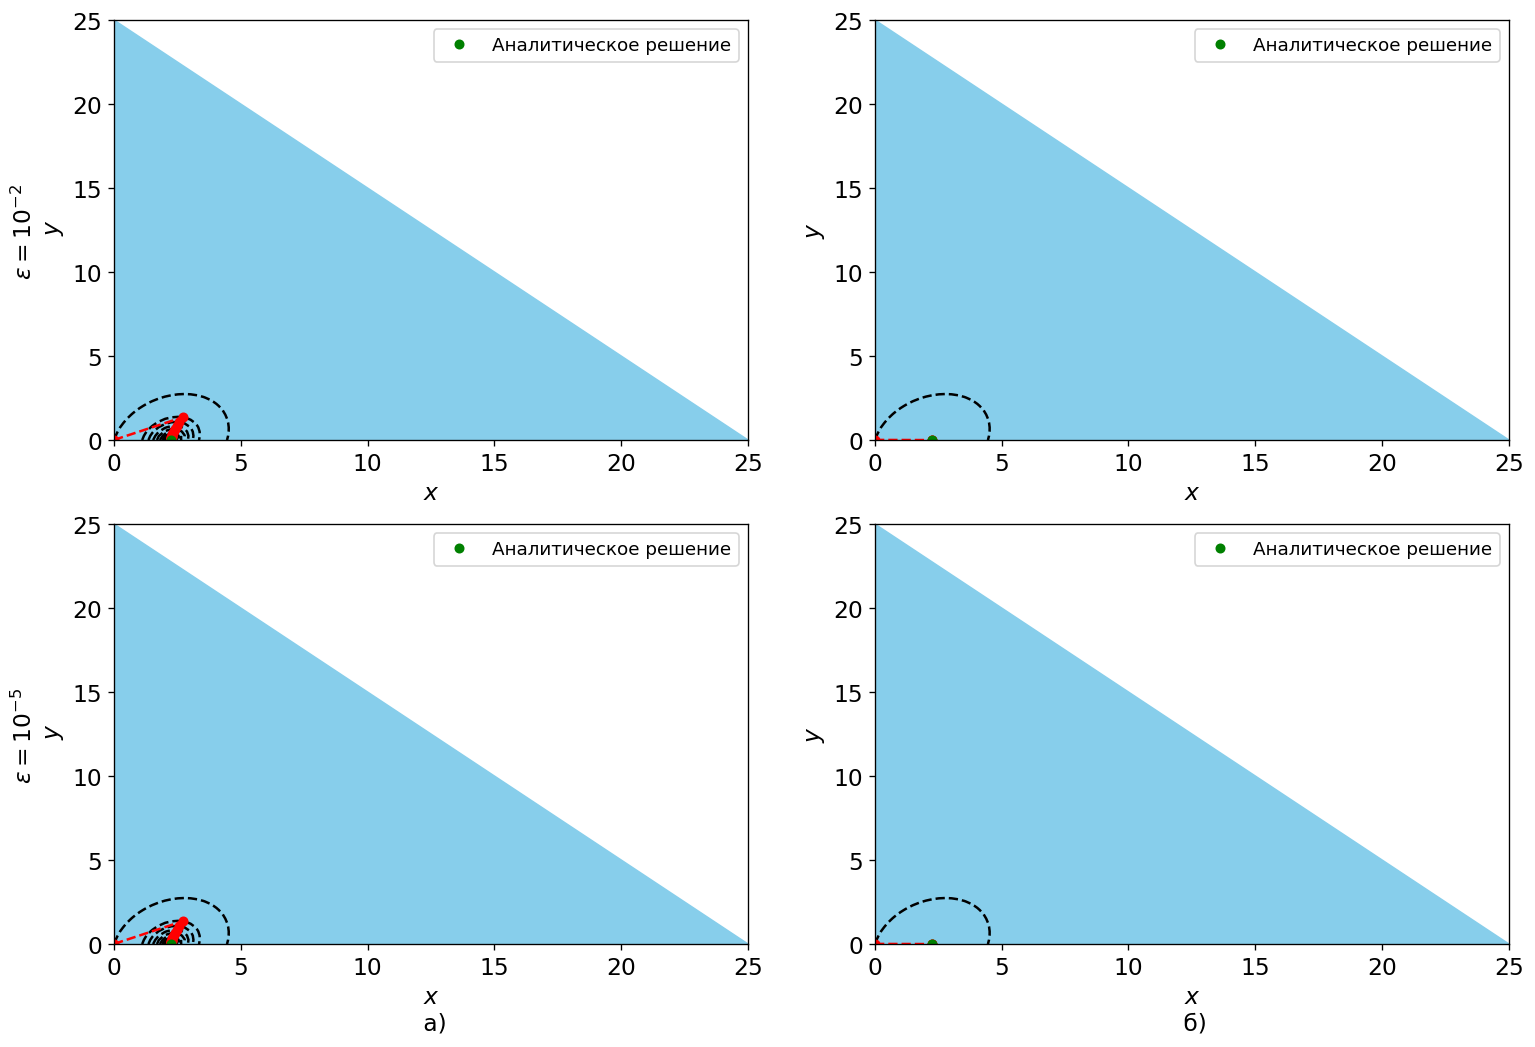

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega1_eps1_p1
m1_eps2 = inner_omega1_eps2_p1
m2_eps1 = outer_omega1_eps1_p1
m2_eps2 = outer_omega1_eps2_p1
g = [g1_1, g1_2, g1_3]
f =f
leftx, rightx = [0, 25]
lefty, righty = [0,25]
points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'r--')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'r--')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'r--')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'r--')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(np.sqrt(5),0, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

# for cur_g in g:
#     x = np.linspace(-1,25, 100)
#     y = np.linspace(-1,25, 100)
#     X, Y = np.meshgrid(x,y)
#     Z = cur_g([X,Y])

for i in range(2):
    for j in range(2):
        # ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
        ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
        # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

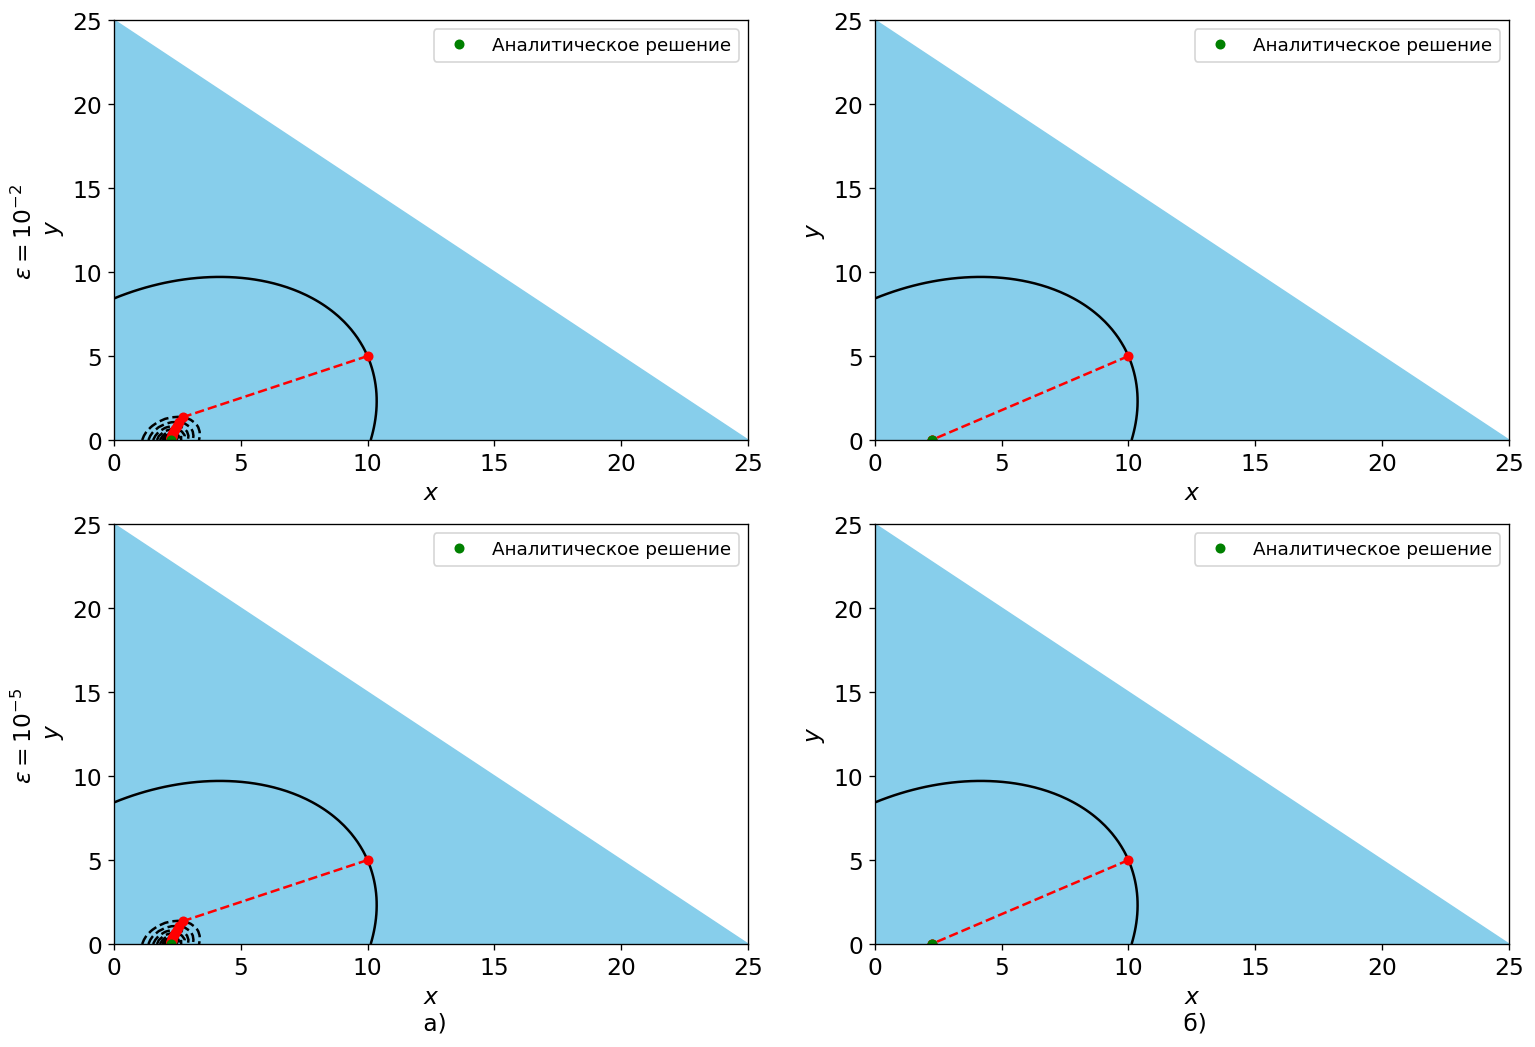

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega1_eps1_p2
m1_eps2 = inner_omega1_eps2_p2
m2_eps1 = outer_omega1_eps1_p2
m2_eps2 = outer_omega1_eps2_p2
g = [g1_1, g1_2, g1_3]
f = f
leftx, rightx = [0, 25]
lefty, righty = [0,25]
points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'r--')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'r--')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'r--')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'r--')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(np.sqrt(5),0, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

# for cur_g in g:
#     x = np.linspace(-1,25, 100)
#     y = np.linspace(-1,25, 100)
#     X, Y = np.meshgrid(x,y)
#     Z = cur_g([X,Y])

for i in range(2):
    for j in range(2):
        # ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
        ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
        # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

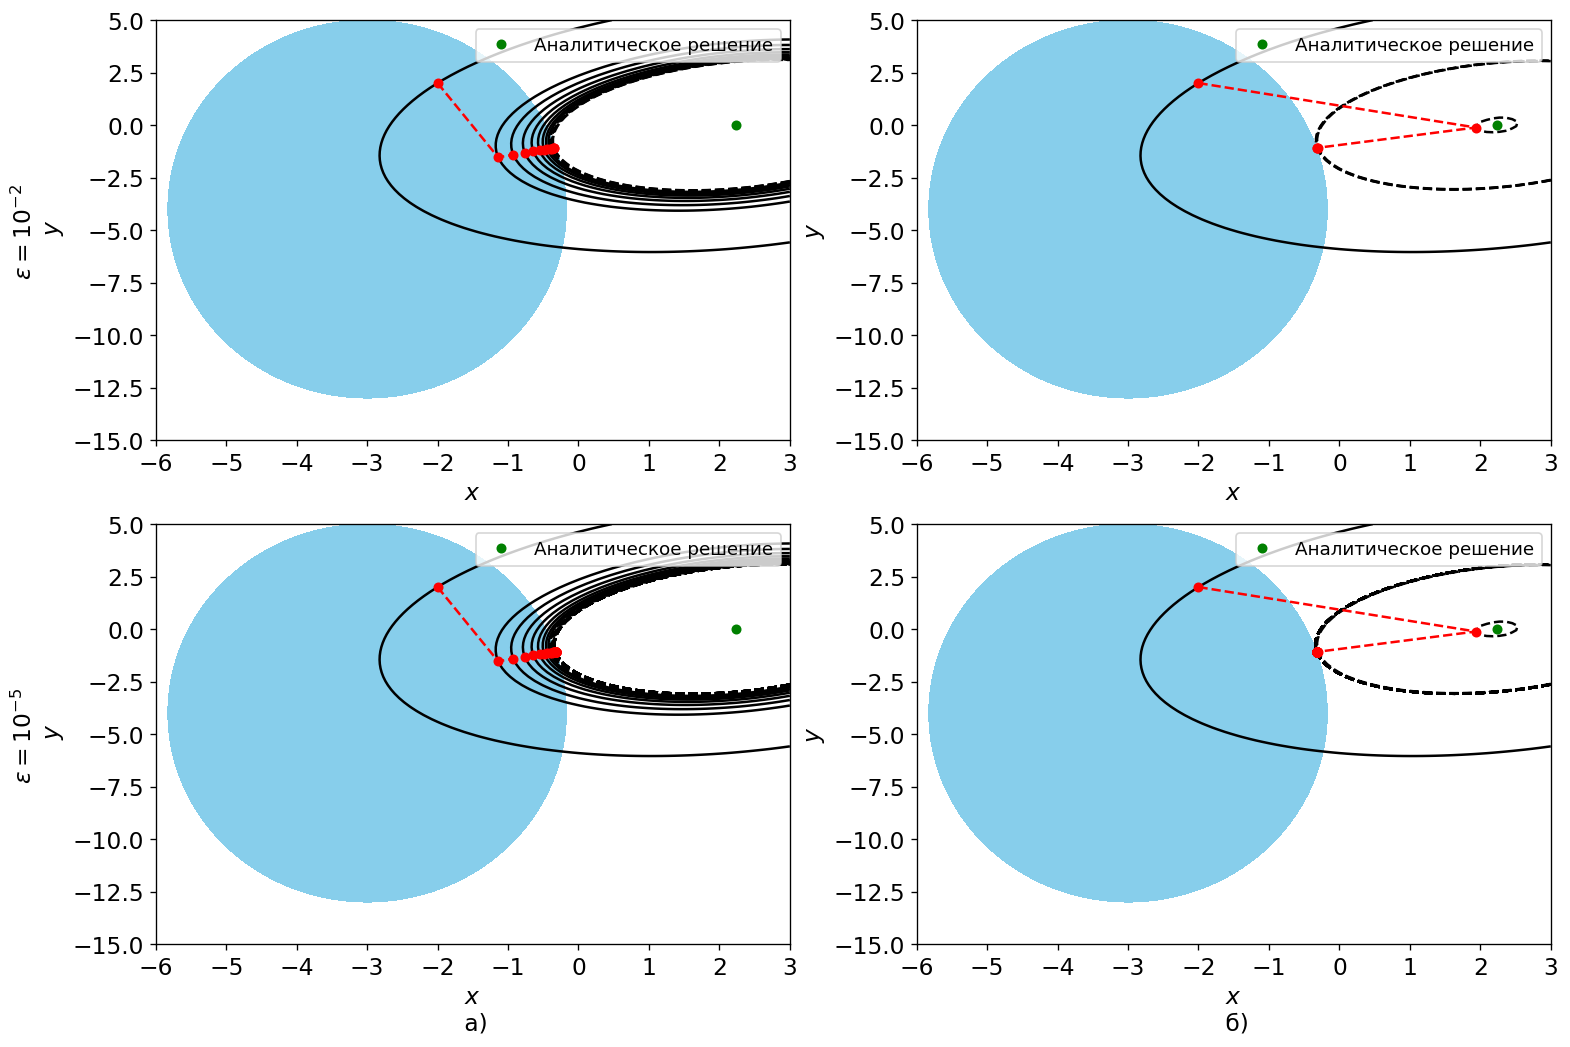

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega2_eps1_p1
m1_eps2 = inner_omega2_eps2_p1
m2_eps1 = outer_omega2_eps1_p1
m2_eps2 = outer_omega2_eps2_p1
g = [g2]

f = f
leftx, rightx = [-6, 3]
lefty, righty = [-15,5]


points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'r--')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'r--')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'r--')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])

x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'r--')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(np.sqrt(5),0, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

for cur_g in g:
    x = np.linspace(-6,0, 100)
    y = np.linspace(-15,5, 100)
    X, Y = np.meshgrid(x,y)
    Z = cur_g([X,Y])
    for i in range(2):
        for j in range(2):
            ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
            # ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
            # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

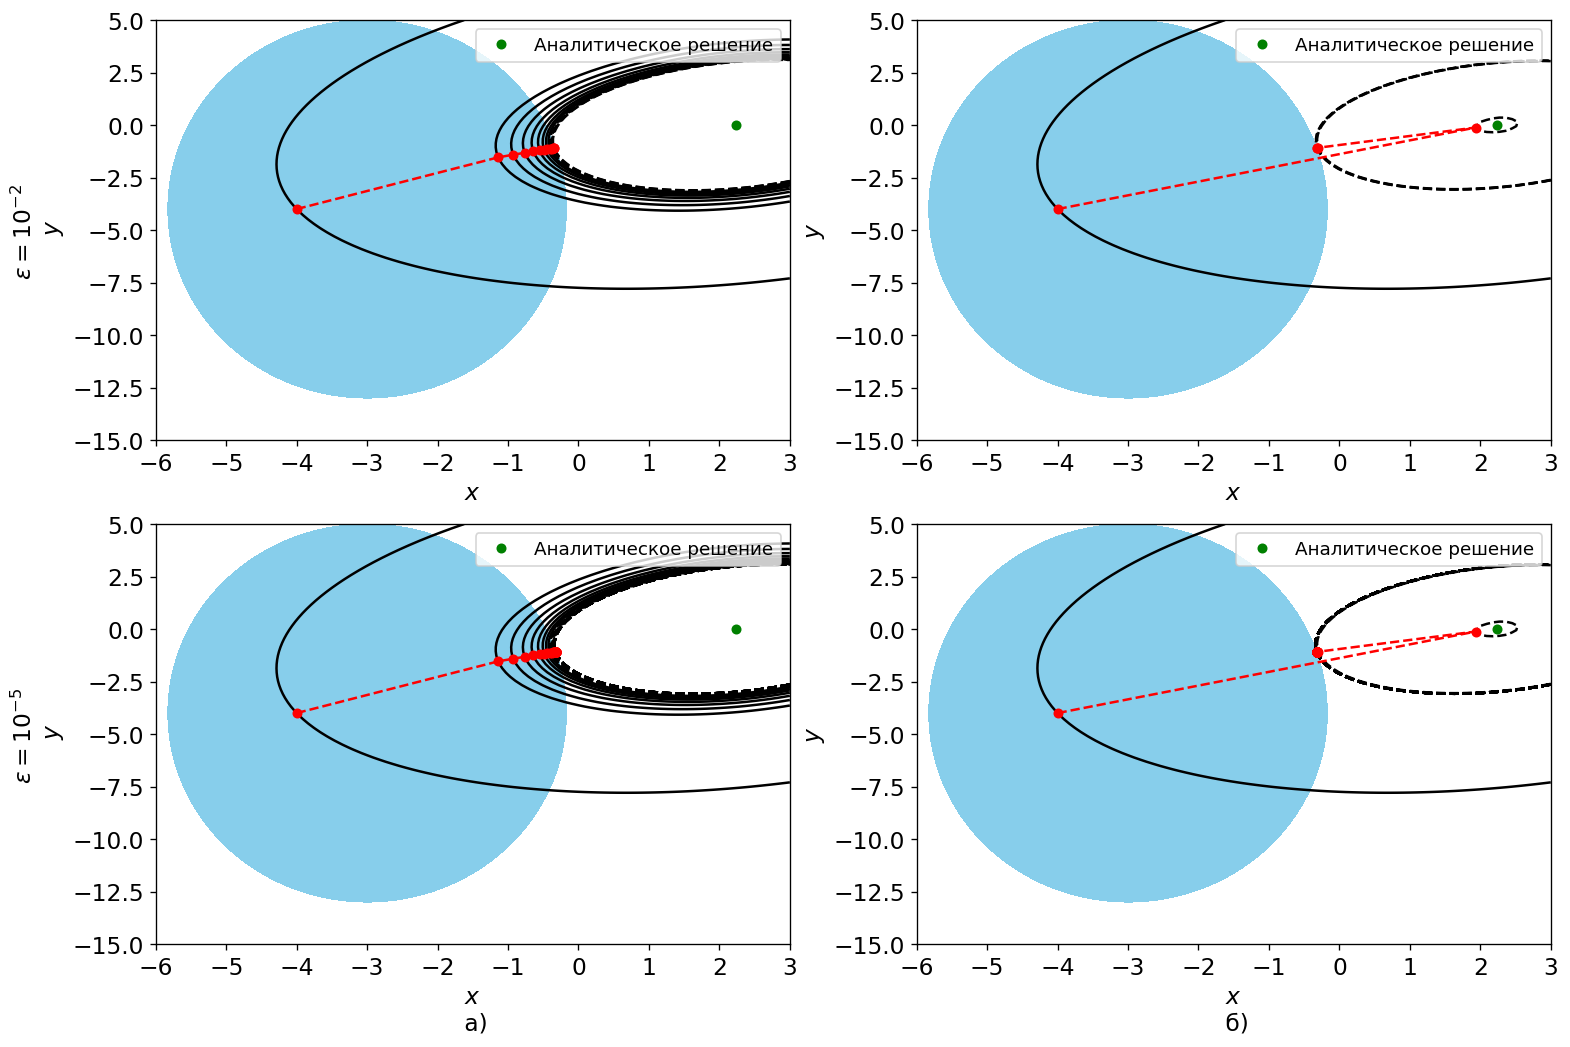

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega2_eps1_p2
m1_eps2 = inner_omega2_eps2_p2
m2_eps1 = outer_omega2_eps1_p2
m2_eps2 = outer_omega2_eps2_p2
g = [g2]

f = f
leftx, rightx = [-6, 3]
lefty, righty = [-15,5]


points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'r--')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'r--')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'r--')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])

x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'r--')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(np.sqrt(5),0, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

for cur_g in g:
    x = np.linspace(-6,0, 100)
    y = np.linspace(-15,5, 100)
    X, Y = np.meshgrid(x,y)
    Z = cur_g([X,Y])
    for i in range(2):
        for j in range(2):
            ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
            # ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
            # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

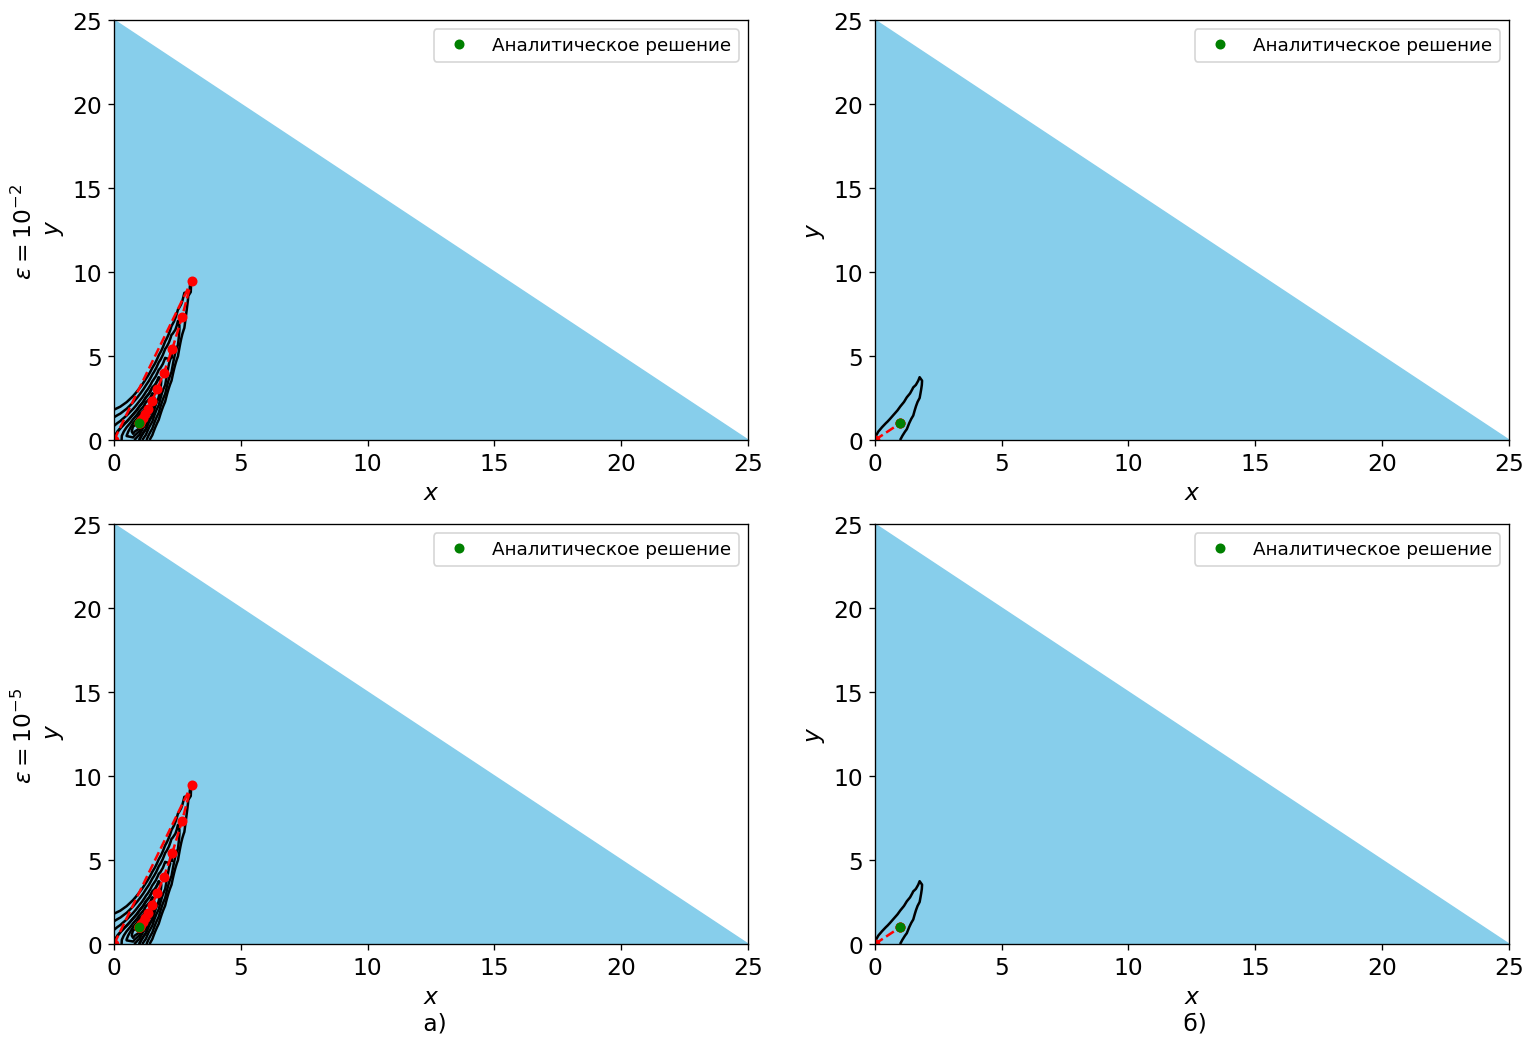

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega1_eps1_p1_r1
m1_eps2 = inner_omega1_eps2_p1_r1
m2_eps1 = outer_omega1_eps1_p1_r1
m2_eps2 = outer_omega1_eps2_p1_r1
g = [g1_1, g1_2, g1_3]
f = rosenbrock1

leftx, rightx = [0, 25]
lefty, righty = [0,25]
points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'r--')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'r--')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'r--')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'r--')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

# for cur_g in g:
#     x = np.linspace(-1,25, 100)
#     y = np.linspace(-1,25, 100)
#     X, Y = np.meshgrid(x,y)
#     Z = cur_g([X,Y])

for i in range(2):
    for j in range(2):
        # ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
        ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
        # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

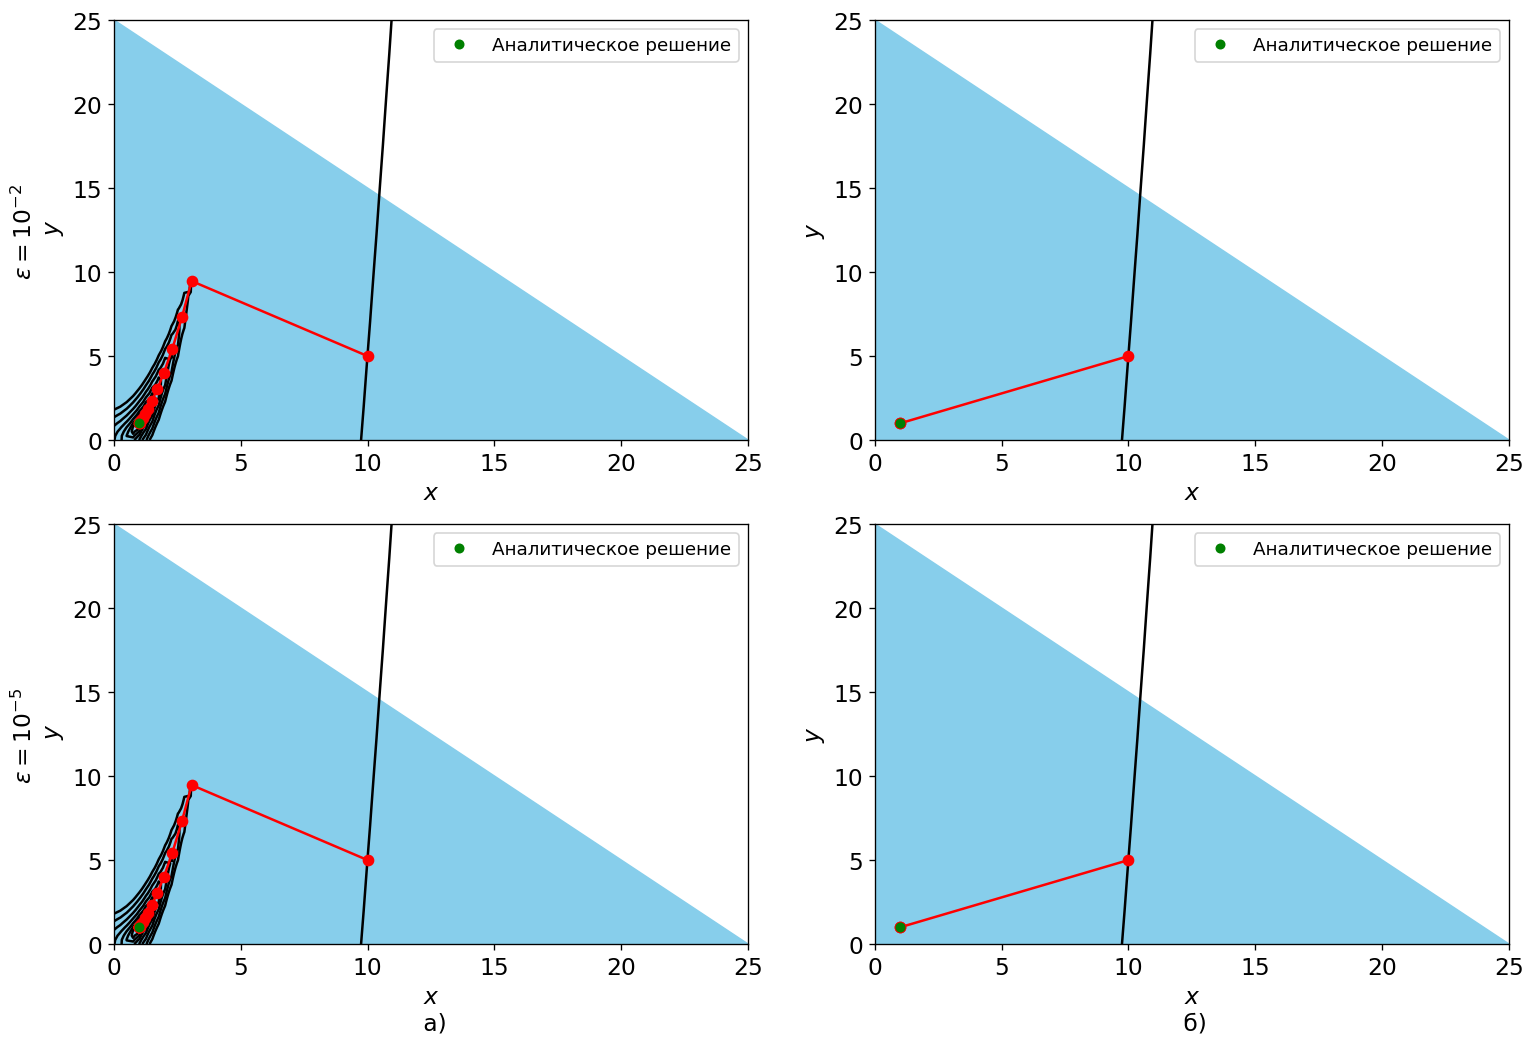

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega1_eps1_p2_r1
m1_eps2 = inner_omega1_eps2_p2_r1
m2_eps1 = outer_omega1_eps1_p2_r1
m2_eps2 = outer_omega1_eps2_p2_r1
g = [g1_1, g1_2, g1_3]
f = rosenbrock1

leftx, rightx = [0, 25]
lefty, righty = [0,25]
points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

# for cur_g in g:
#     x = np.linspace(-1,25, 100)
#     y = np.linspace(-1,25, 100)
#     X, Y = np.meshgrid(x,y)
#     Z = cur_g([X,Y])

for i in range(2):
    for j in range(2):
        # ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
        ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
        # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

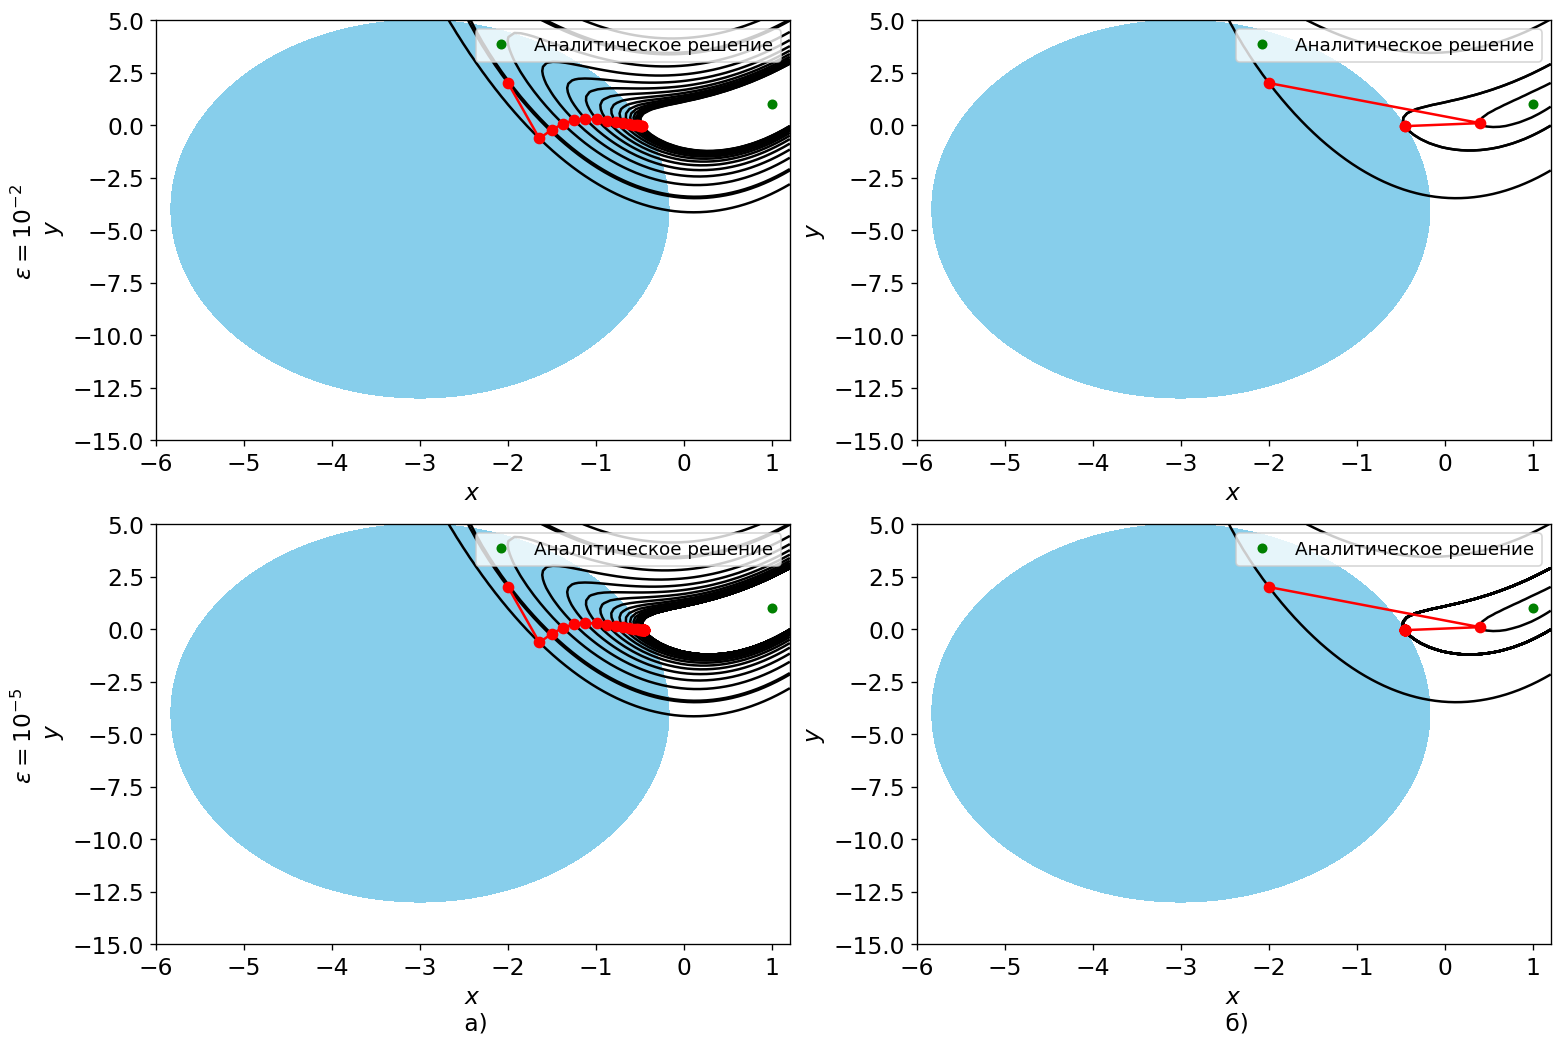

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega2_eps1_p1_r1
m1_eps2 = inner_omega2_eps2_p1_r1
m2_eps1 = outer_omega2_eps1_p1_r1
m2_eps2 = outer_omega2_eps2_p1_r1
g = [g2]
f = rosenbrock1

leftx, rightx = [-6, 1.2]
lefty, righty = [-15,5]


points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])

x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

for cur_g in g:
    x = np.linspace(-6,0, 100)
    y = np.linspace(-15,5, 100)
    X, Y = np.meshgrid(x,y)
    Z = cur_g([X,Y])
    for i in range(2):
        for j in range(2):
            ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
            # ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
            # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

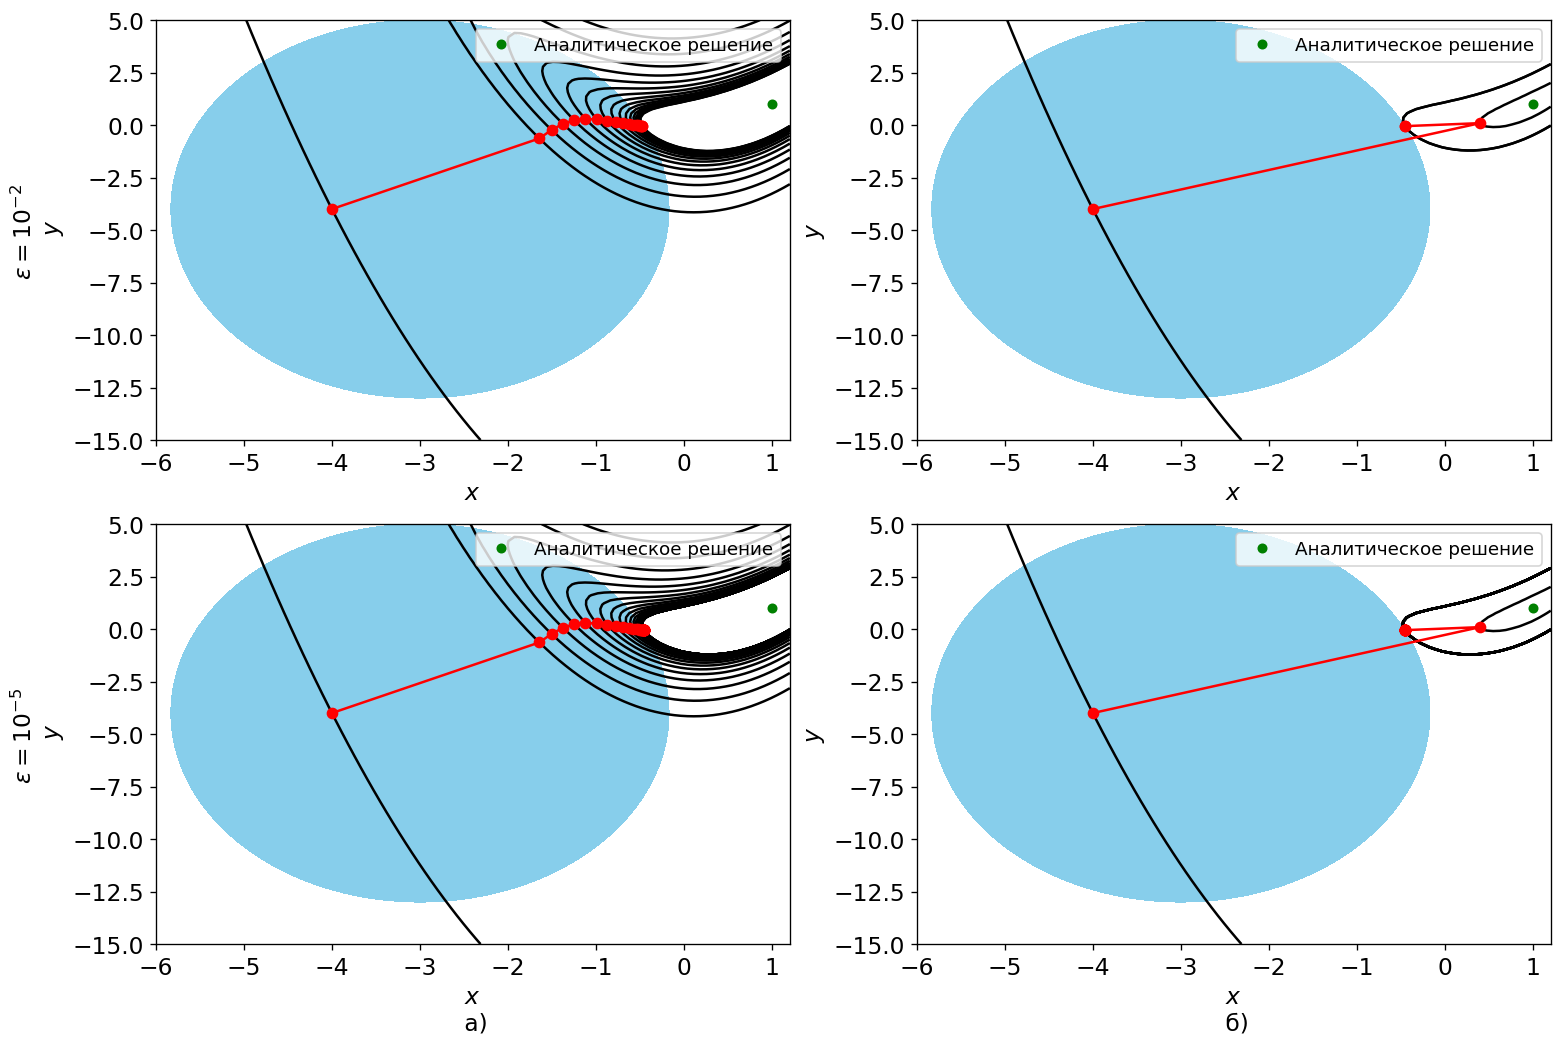

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega2_eps1_p2_r1
m1_eps2 = inner_omega2_eps2_p2_r1
m2_eps1 = outer_omega2_eps1_p2_r1
m2_eps2 = outer_omega2_eps2_p2_r1
g = [g2]
f = rosenbrock1

leftx, rightx = [-6, 1.2]
lefty, righty = [-15,5]


points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])

x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

for cur_g in g:
    x = np.linspace(-6,0, 100)
    y = np.linspace(-15,5, 100)
    X, Y = np.meshgrid(x,y)
    Z = cur_g([X,Y])
    for i in range(2):
        for j in range(2):
            ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
            # ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
            # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

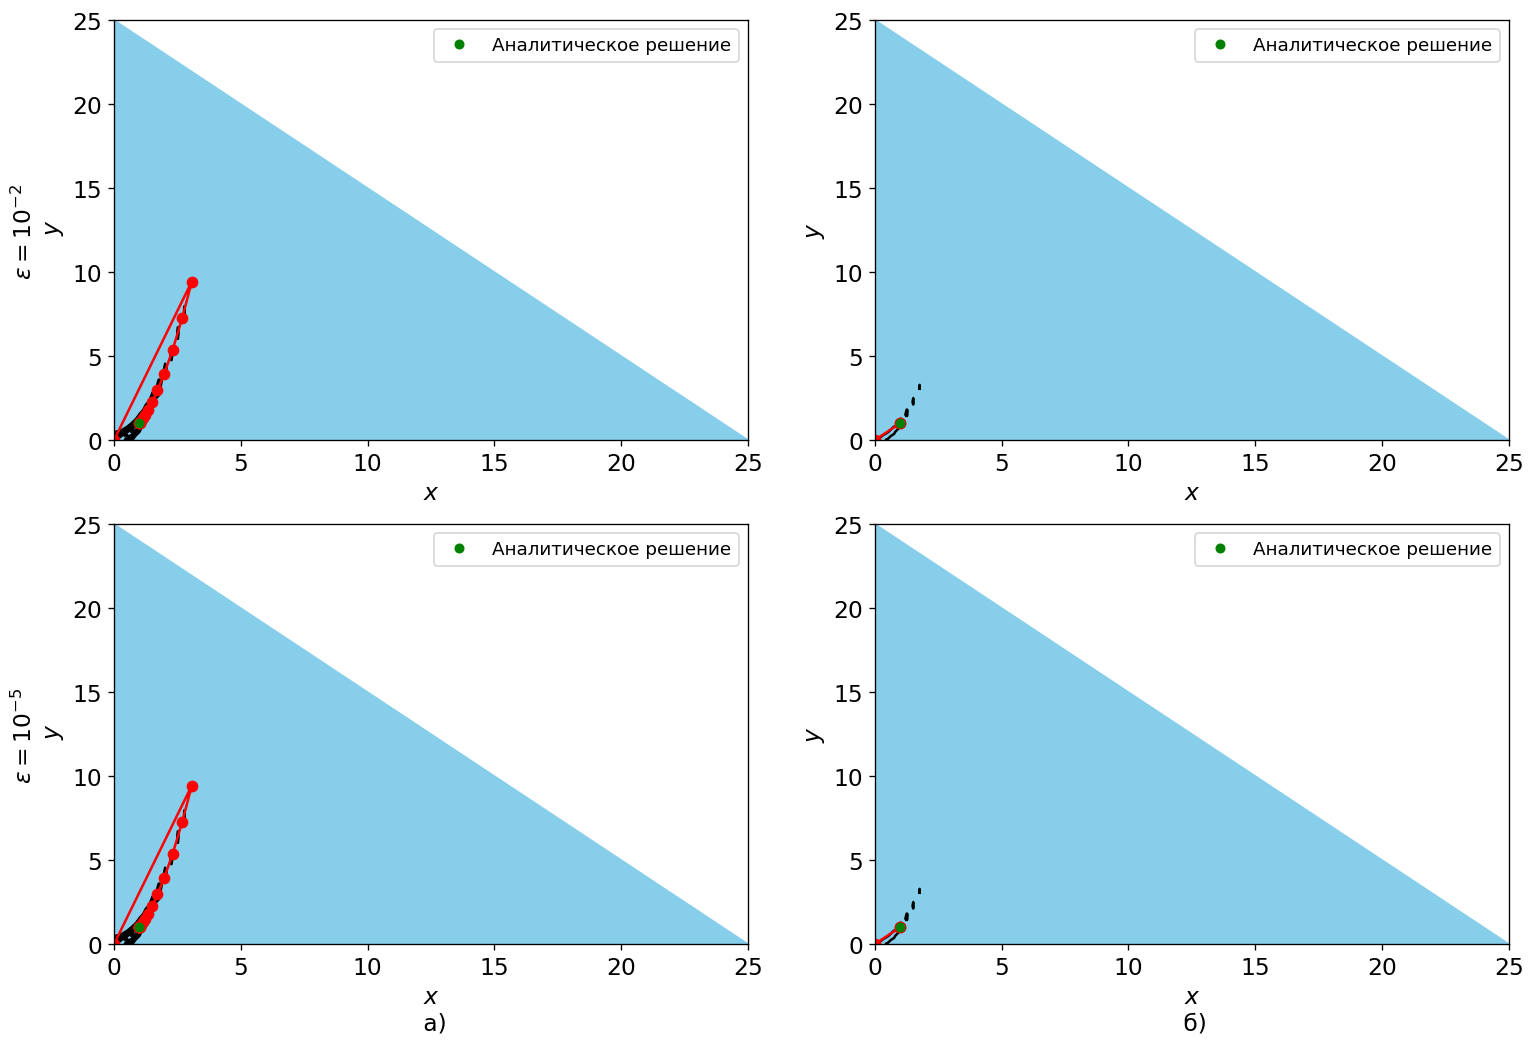

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega1_eps1_p1_r2
m1_eps2 = inner_omega1_eps2_p1_r2
m2_eps1 = outer_omega1_eps1_p1_r2
m2_eps2 = outer_omega1_eps2_p1_r2
g = [g1_1, g1_2, g1_3]
f = rosenbrock2

leftx, rightx = [0, 25]
lefty, righty = [0,25]
points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

# for cur_g in g:
#     x = np.linspace(-1,25, 100)
#     y = np.linspace(-1,25, 100)
#     X, Y = np.meshgrid(x,y)
#     Z = cur_g([X,Y])

for i in range(2):
    for j in range(2):
        # ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
        ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
        # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

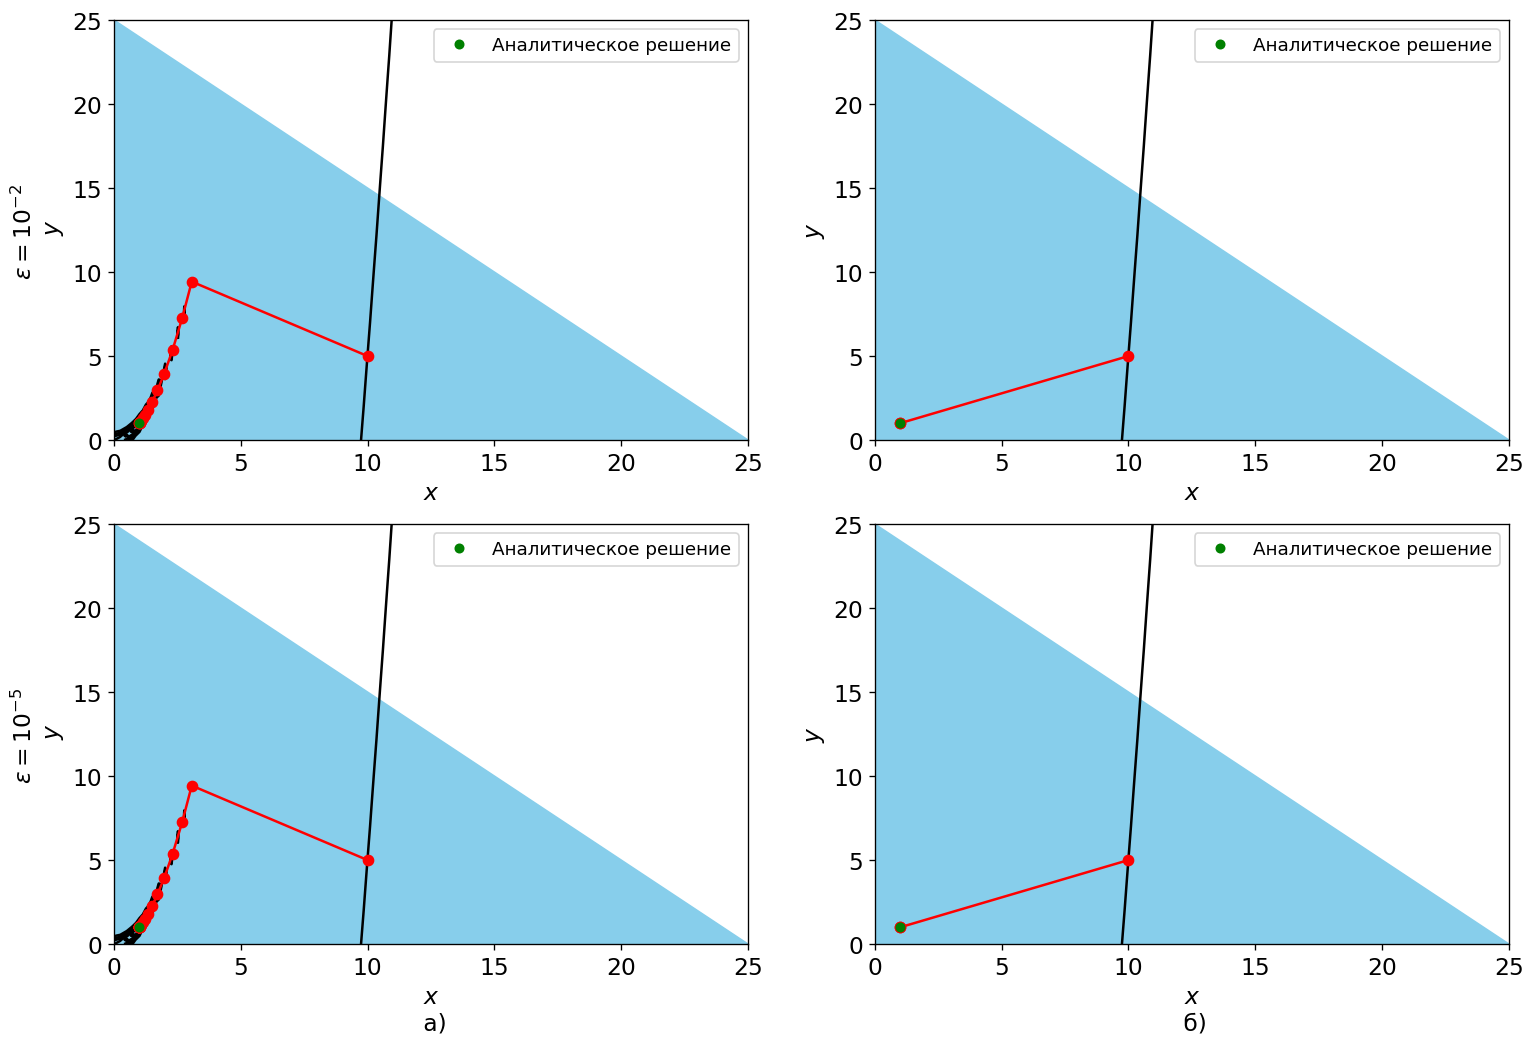

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega1_eps1_p2_r2
m1_eps2 = inner_omega1_eps2_p2_r2
m2_eps1 = outer_omega1_eps1_p2_r2
m2_eps2 = outer_omega1_eps2_p2_r2
g = [g1_1, g1_2, g1_3]
f = rosenbrock2
leftx, rightx = [0, 25]
lefty, righty = [0,25]
points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

# for cur_g in g:
#     x = np.linspace(-1,25, 100)
#     y = np.linspace(-1,25, 100)
#     X, Y = np.meshgrid(x,y)
#     Z = cur_g([X,Y])

for i in range(2):
    for j in range(2):
        # ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
        ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
        # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

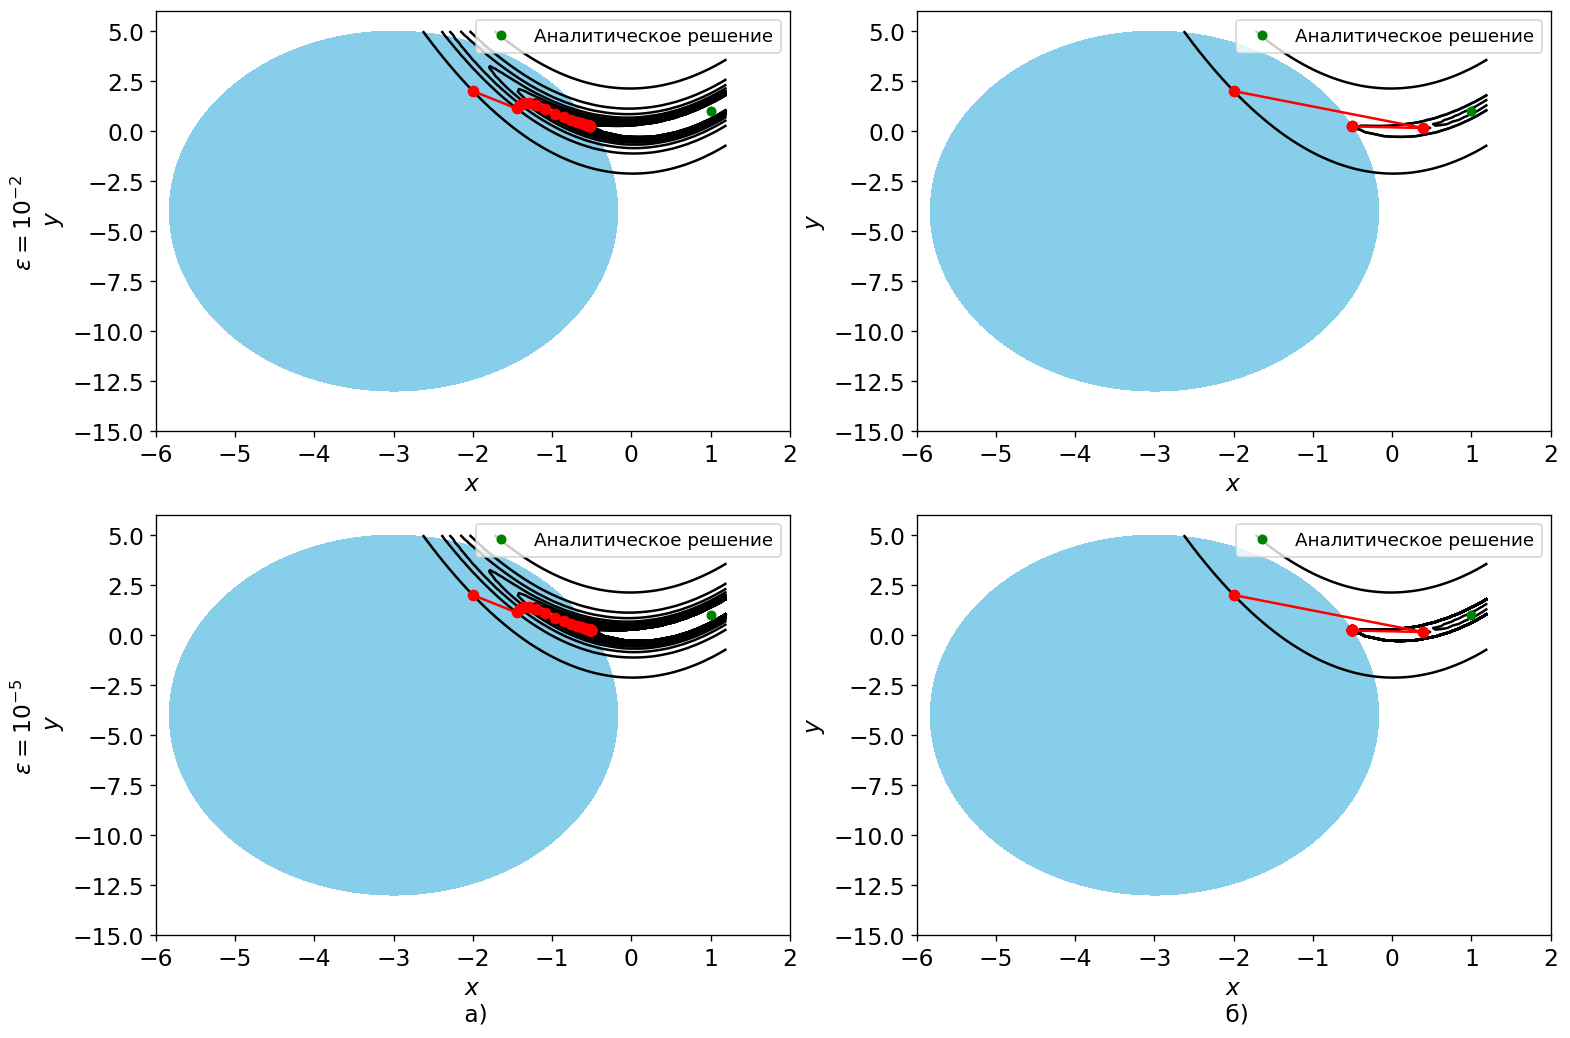

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega2_eps1_p1_r2
m1_eps2 = inner_omega2_eps2_p1_r2
m2_eps1 = outer_omega2_eps1_p1_r2
m2_eps2 = outer_omega2_eps2_p1_r2
g = [g2]
f = rosenbrock2
leftx, rightx = [-6, 1.2]
lefty, righty = [-15,5]

points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

for cur_g in g:
    x = np.linspace(-6,2, 100)
    y = np.linspace(-15,6, 100)
    X, Y = np.meshgrid(x,y)
    Z = cur_g([X,Y])
    for i in range(2):
        for j in range(2):
            ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
            # ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
            # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

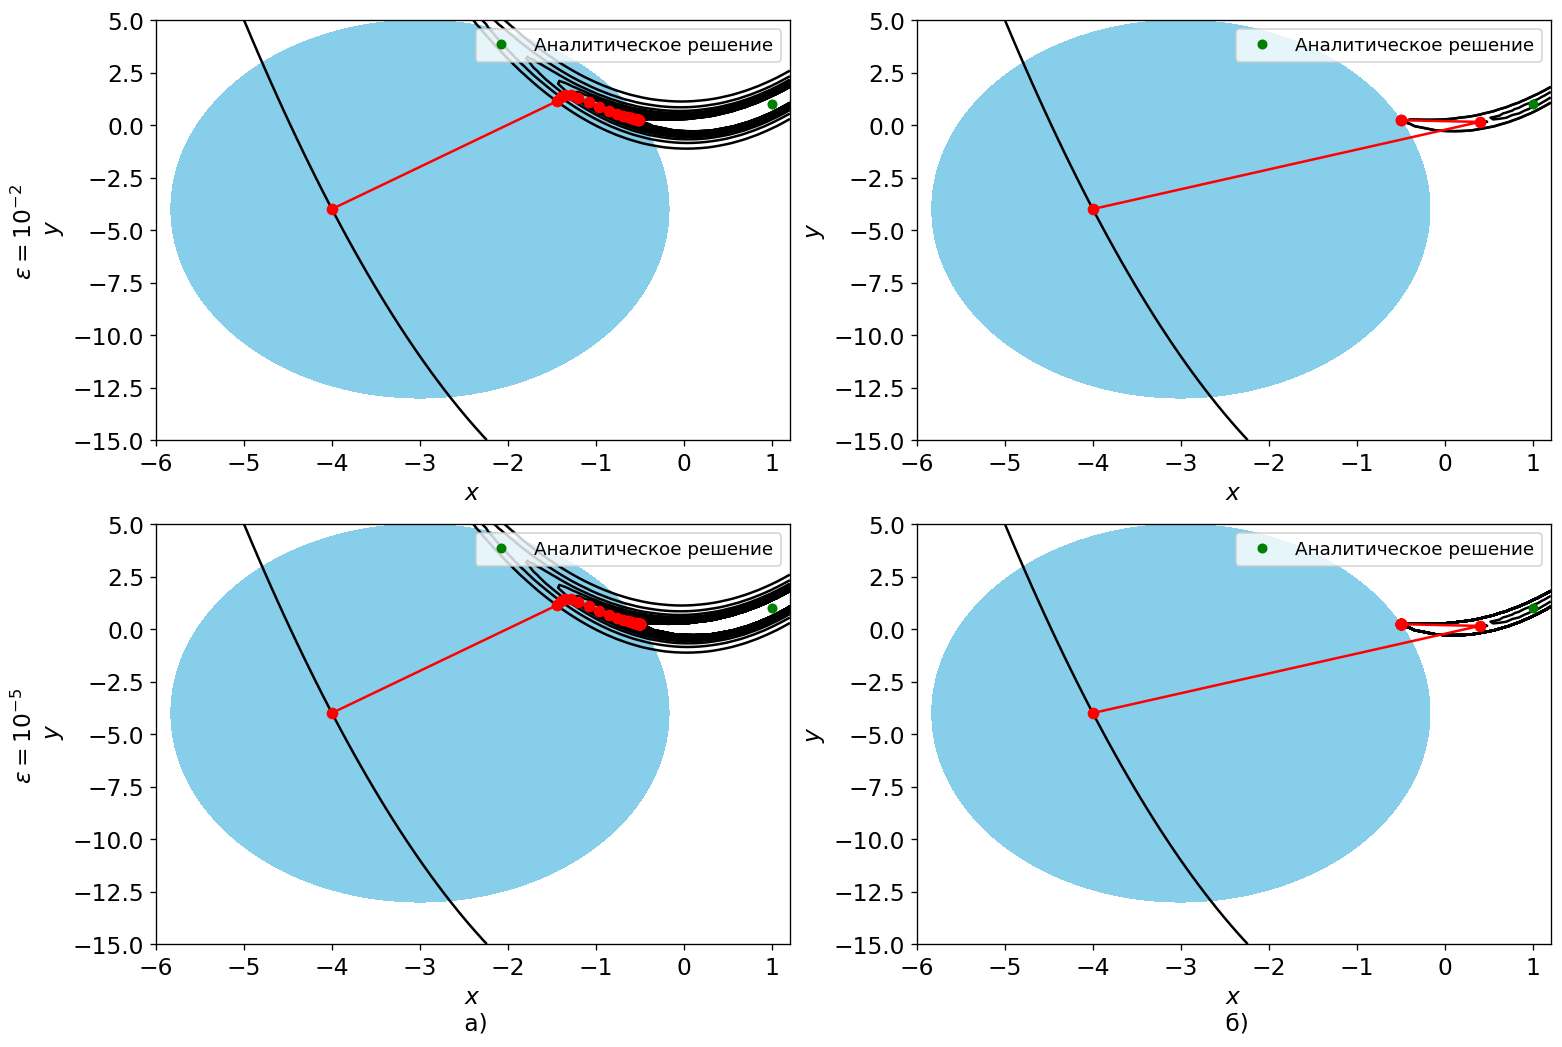

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(2,2, figsize=(15,10),dpi=120)
m1_eps1 = inner_omega2_eps1_p2_r2
m1_eps2 = inner_omega2_eps2_p2_r2
m2_eps1 = outer_omega2_eps1_p2_r2
m2_eps2 = outer_omega2_eps2_p2_r2
g = [g2]
f = rosenbrock2
leftx, rightx = [-6, 1.2]
lefty, righty = [-15,5]


points = np.array(m1_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps1[-1]))), colors = 'k')
ax[0,0].plot(points[:,0], points[:,1], 'ro-')
ax[0,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m2_eps1[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[0,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps1[-1]))), colors = 'k')
ax[0,1].plot(points[:,0], points[:,1], 'ro-')
ax[0,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)


points = np.array(m2_eps2[-2])
min_x = points[:, 0].min()
max_x = points[:, 0].max()
min_y = points[:, 1].min()
max_y = points[:, 1].max()
x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,1].contour(X,Y,Z,  levels = sorted(list(set(m2_eps2[-1]))), colors = 'k')
ax[1,1].plot(points[:,0], points[:,1], 'ro-')
ax[1,1].plot(points[:,0], points[:,1], 'ro', markersize = 5)

points = np.array(m1_eps2[-2])

x = np.linspace(leftx,rightx, 100)
y = np.linspace(lefty,righty,100)
X, Y = np.meshgrid(x,y)
Z = f([X,Y])
ax[1,0].contour(X,Y,Z,  levels = sorted(list(set(m1_eps2[-1]))), colors = 'k')
ax[1,0].plot(points[:,0], points[:,1], 'ro-')
ax[1,0].plot(points[:,0], points[:,1], 'ro', markersize = 5)



ax[0,0].set_xlabel("$x$")
ax[0,1].set_xlabel("$x$")
ax[1,0].set_xlabel("$x$ \n а)")
ax[1,1].set_xlabel("$x$ \n б)")
ax[0,0].set_ylabel("$\\varepsilon = 10^{-2}$ \n $y$")
ax[1,0].set_ylabel("$\\varepsilon = 10^{-5}$ \n $y$")
ax[0,1].set_ylabel("$y$")
ax[1,1].set_ylabel("$y$")

for i in range(2):
    for j in range(2):
        ax[i,j].plot(1,1, "go", label="Аналитическое решение", markersize=5)
        ax[i,j].legend( prop = { "size": 11 })

for cur_g in g:
    x = np.linspace(-6,0, 100)
    y = np.linspace(-15,5, 100)
    X, Y = np.meshgrid(x,y)
    Z = cur_g([X,Y])
    for i in range(2):
        for j in range(2):
            ax[i,j].contourf(X,Y,Z, levels = [-1,0], colors="skyblue")
            # ax[i, j].fill([0,0,25],[0,25,0], color="skyblue")
            # ax[i,j].plot([0,0,25,0],[0,25,0,0], color="k")

# Выводы
В качестве внутреннего метода оптимизации выбран метод Ньютона, так как он
сходится за меньшее число итераций по сравнению с ранее рассмотренными
методами безусловной минимизации.

По результатам работы программы метод внешних штрафных функций работает стабильно лучше метода внутренних штрафных функций (стоимость меньше в
4-5 раз в случае функции Розенброка). Первая итерация методов делает большой
шаг в сторону точки минимума, а следующие уточняют её положение с изменением
штрафной функции. В случае нахождения точки минимума функции за границей
допустимого множества алгоритмы сходятся медленнее к локальному минимуму на
границе.